# Runtime Model Inference Example

This notebook demonstrates how to use the `runtime_inference` library to:
1. Load a trained Runtime Transformer model from a checkpoint
2. Perform inference on raw training examples
3. Get probability distributions over pace bins

The library automatically handles all data transformations (standard, ablation, shuffled ablation) based on the model's configuration.


In [2]:
# --- IMPORTS AND SETUP ---
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import importlib
import pickle 

# Import the inference library and dataclasses
from runtime_inference import (
    RuntimeModelInference,
    TrainingExample,
    RunnerForTraining
)

# Reload the module to ensure we get the latest version (useful if library was updated)
import runtime_inference
importlib.reload(runtime_inference)
from runtime_inference import (
    RuntimeModelInference,
    TrainingExample,
    RunnerForTraining
)

# Set up device (CPU is safest for compatibility)
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
import torch
DEVICE = torch.device("cpu")  # Change to "cuda" or "mps" if available

print(f"Using device: {DEVICE}")


Using device: cpu


## Step 1: Define File Paths

Update these paths to point to your checkpoint, config, and pace lookup files.


In [3]:
# --- FILE PATHS ---
# Update these to match your setup

BASE_DIR = "/Users/yaelelmatad/Desktop/nyrr-transform/Runtime/train/ablation-studies"
PACE_LOOKUP_PATH = "/Users/yaelelmatad/Desktop/nyrr-transform/Runtime/data/pace_lookup.pickle"

# Model 1: Swapped Order (Corrected)
CHECKPOINT_PATH_1 = f"{BASE_DIR}/Production_Scale_v2_HighCap_SwappedOrder_Corrected/best_model.pt"
CONFIG_PATH_1 = f"{BASE_DIR}/Production_Scale_v2_HighCap_SwappedOrder_Corrected/config_copy.yaml"
MODEL_NAME_1 = "SwappedOrder"

# Model 2: Ablation (No Time, Age Last Front) (Corrected)
CHECKPOINT_PATH_2 = f"{BASE_DIR}/Production_Scale_v2_HighCap_Ablation_NoTime_AgeLastFront_Corrected/best_model.pt"
CONFIG_PATH_2 = f"{BASE_DIR}/Production_Scale_v2_HighCap_Ablation_NoTime_AgeLastFront_Corrected/config_copy.yaml"
MODEL_NAME_2 = "Ablation"

# Model 3: Ablation Shuffled (Corrected)
CHECKPOINT_PATH_3 = f"{BASE_DIR}/Production_Scale_v2_HighCap_Ablation_NoTime_AgeLastFront_Shuffled_Corrected/best_model.pt"
CONFIG_PATH_3 = f"{BASE_DIR}/Production_Scale_v2_HighCap_Ablation_NoTime_AgeLastFront_Shuffled_Corrected/config_copy.yaml"
MODEL_NAME_3 = "AblationShuffled"

# Model 4: SwappedOrder Lambda 1 (Corrected) - was Lambda 40
CHECKPOINT_PATH_4 = f"{BASE_DIR}/Production_Scale_v2_HighCap_SwappedOrder_Corrected_Lambda_1/best_model.pt"
CONFIG_PATH_4 = f"{BASE_DIR}/Production_Scale_v2_HighCap_SwappedOrder_Corrected_Lambda_1/config_copy.yaml"
MODEL_NAME_4 = "SwappedOrder_Lambda1"

# Model 5: SwappedOrder Lambda 35 (from _74 run)
CHECKPOINT_PATH_5 = f"{BASE_DIR}/Production_Scale_v2_HighCap_SwappedOrder_74/best_model.pt"
CONFIG_PATH_5 = f"{BASE_DIR}/Production_Scale_v2_HighCap_SwappedOrder_74/config_copy.yaml"
MODEL_NAME_5 = "SwappedOrder_Lambda35"

# Model 6: SwappedOrder Lambda 4 (Corrected) - was Lambda 50
CHECKPOINT_PATH_6 = f"{BASE_DIR}/Production_Scale_v2_HighCap_SwappedOrder_Corrected_Lambda_4/best_model.pt"
CONFIG_PATH_6 = f"{BASE_DIR}/Production_Scale_v2_HighCap_SwappedOrder_Corrected_Lambda_4/config_copy.yaml"
MODEL_NAME_6 = "SwappedOrder_Lambda4"

# Model 7: SwappedOrder Lambda 5 (Corrected) - was Lambda 55
CHECKPOINT_PATH_7 = f"{BASE_DIR}/Production_Scale_v2_HighCap_SwappedOrder_Corrected_Lambda_5/best_model.pt"
CONFIG_PATH_7 = f"{BASE_DIR}/Production_Scale_v2_HighCap_SwappedOrder_Corrected_Lambda_5/config_copy.yaml"
MODEL_NAME_7 = "SwappedOrder_Lambda5"

# Training splits glob pattern
TRAINING_SPLITS_GLOB = "/Users/yaelelmatad/Desktop/nyrr-transform/Runtime/pipeline/training_splits/runners_split_[0][8][0-9].pkl.gz"

# XGBoost baseline paths (optional - for comparison)
# Using same version as Inspect_Model_Outputs.ipynb
XGB_MODEL_PATH = "/Users/yaelelmatad/Desktop/nyrr-transform/Runtime/train/xgb_first_50_continuous/xgboost_model.json"
XGB_FEATURE_COLUMNS_PATH = "/Users/yaelelmatad/Desktop/nyrr-transform/Runtime/train/xgb_first_50_continuous/xgboost_feature_columns.pickle"

# Distance mapping for XGBoost
DISTANCE_MAP = {
    'distance_name_token_1_mile': 1.0, 'distance_name_token_1POINT5_miles': 1.5,
    'distance_name_token_3_miles': 3.0, 'distance_name_token_3_kilometers': 1.86411,
    'distance_name_token_5_kilometers': 3.10686, 'distance_name_token_4_miles': 4.0,
    'distance_name_token_5_miles': 5.0, 'distance_name_token_8_kilometers': 4.97097,
    'distance_name_token_10_kilometers': 6.21371, 'distance_name_token_12_kilometers': 7.45645,
    'distance_name_token_15_kilometers': 9.32057, 'distance_name_token_10_miles': 10.0,
    'distance_name_token_18_miles': 18.0, 'distance_name_token_20_kilometers': 12.4274,
    'distance_name_token_25_kilometers': 15.5343, 'distance_name_token_30_kilometers': 18.6411,
    'distance_name_token_half_marathon': 13.1094, 'distance_name_token_marathon': 26.2188
}

print("File paths configured:")
print(f"  Model 1 ({MODEL_NAME_1}):")
print(f"    Checkpoint: {CHECKPOINT_PATH_1}")
print(f"    Config: {CONFIG_PATH_1}")
print(f"  Model 2 ({MODEL_NAME_2}):")
print(f"    Checkpoint: {CHECKPOINT_PATH_2}")
print(f"    Config: {CONFIG_PATH_2}")
print(f"  Model 3 ({MODEL_NAME_3}):")
print(f"    Checkpoint: {CHECKPOINT_PATH_3}")
print(f"    Config: {CONFIG_PATH_3}")
print(f"  Model 4 ({MODEL_NAME_4}):")
print(f"    Checkpoint: {CHECKPOINT_PATH_4}")
print(f"    Config: {CONFIG_PATH_4}")
print(f"  Model 5 ({MODEL_NAME_5}):")
print(f"    Checkpoint: {CHECKPOINT_PATH_5}")
print(f"    Config: {CONFIG_PATH_5}")
print(f"  Model 6 ({MODEL_NAME_6}):")
print(f"    Checkpoint: {CHECKPOINT_PATH_6}")
print(f"    Config: {CONFIG_PATH_6}")
print(f"  Model 7 ({MODEL_NAME_7}):")
print(f"    Checkpoint: {CHECKPOINT_PATH_7}")
print(f"    Config: {CONFIG_PATH_7}")
print(f"  Pace lookup: {PACE_LOOKUP_PATH}")
print(f"  Training splits glob: {TRAINING_SPLITS_GLOB}")


File paths configured:
  Model 1 (SwappedOrder):
    Checkpoint: /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/train/ablation-studies/Production_Scale_v2_HighCap_SwappedOrder_Corrected/best_model.pt
    Config: /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/train/ablation-studies/Production_Scale_v2_HighCap_SwappedOrder_Corrected/config_copy.yaml
  Model 2 (Ablation):
    Checkpoint: /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/train/ablation-studies/Production_Scale_v2_HighCap_Ablation_NoTime_AgeLastFront_Corrected/best_model.pt
    Config: /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/train/ablation-studies/Production_Scale_v2_HighCap_Ablation_NoTime_AgeLastFront_Corrected/config_copy.yaml
  Model 3 (AblationShuffled):
    Checkpoint: /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/train/ablation-studies/Production_Scale_v2_HighCap_Ablation_NoTime_AgeLastFront_Shuffled_Corrected/best_model.pt
    Config: /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/train/ablati

In [4]:
# --- MODEL LABELS, COLORS, AND MARKERS ---
# Centralized definitions for all plots and tables
# Order: Lambda 1, 3, 4, 5, 35, then Ablation models

# Display labels for all models
model_labels = {
    MODEL_NAME_1: 'Full Model, λ = 3',
    MODEL_NAME_2: 'Time Token Ablation',
    MODEL_NAME_3: 'Time Token Ablation with Shuffled Sequence',
    MODEL_NAME_4: 'Full Model, λ = 1',
    MODEL_NAME_5: 'Full Model, λ = 35',
    MODEL_NAME_6: 'Full Model, λ = 4',
    MODEL_NAME_7: 'Full Model, λ = 5',
    'XGBoost': 'XGBoost'
}

# Colors for each model (Lambda runs get distinct colors)
model_colors = {
    MODEL_NAME_1: '#1f77b4',  # blue (Full Model, λ = 3)
    MODEL_NAME_2: '#2ca02c',  # green (Time Token Ablation)
    MODEL_NAME_3: '#d62728',  # orange (Time Token Ablation with Shuffled Sequence)
    MODEL_NAME_4: '#17becf',  # cyan (Full Model, λ = 1)
    MODEL_NAME_5: '#ff7f0e',  # orange-red (Full Model, λ = 35)
    MODEL_NAME_6: '#9467bd',  # purple (Full Model, λ = 4)
    MODEL_NAME_7: '#8c564b',  # brown (Full Model, λ = 5)
    'XGBoost': '#bcbd22'      # olive
}

# Markers for each model
model_markers = {
    MODEL_NAME_1: 'o',  # circle
    MODEL_NAME_2: 's',  # square
    MODEL_NAME_3: '^',  # triangle up
    MODEL_NAME_4: 'v',  # triangle down
    MODEL_NAME_5: '<',  # triangle left (Full Model, λ = 35)
    MODEL_NAME_6: '>',  # triangle right
    MODEL_NAME_7: 'p',  # pentagon
    'XGBoost': 'D'      # diamond
}

# Standard model order for all plots (Lambda 1, 3, 4, 5, 35, then Ablation models)
MODELS_PLOT_ORDER = [MODEL_NAME_4, MODEL_NAME_1, MODEL_NAME_6, MODEL_NAME_7, MODEL_NAME_5, MODEL_NAME_2, MODEL_NAME_3]

print("Model labels, colors, and markers configured:")
print(f"  {len(model_labels)} model labels defined")
print(f"  {len(model_colors)} model colors defined")
print(f"  {len(model_markers)} model markers defined")
print(f"  Plot order: {[model_labels.get(m, m) for m in MODELS_PLOT_ORDER]}")


Model labels, colors, and markers configured:
  8 model labels defined
  8 model colors defined
  8 model markers defined
  Plot order: ['Full Model, λ = 1', 'Full Model, λ = 3', 'Full Model, λ = 4', 'Full Model, λ = 5', 'Full Model, λ = 35', 'Time Token Ablation', 'Time Token Ablation with Shuffled Sequence']


## Step 2: Initialize Inference Engine

The `RuntimeModelInference` class handles all the complexity of loading the model, determining the correct transformations, and preparing sequences.


In [5]:
# Initialize all three inference engines
# This will:
# - Load the checkpoint and config
# - Initialize the model architecture
# - Load pace bins
# - Determine the correct sequence transformation based on config

print("Loading Model 1: SwappedOrder...")
inference_1 = RuntimeModelInference(
    checkpoint_path=CHECKPOINT_PATH_1,
    config_path=CONFIG_PATH_1,
    pace_lookup_path=PACE_LOOKUP_PATH,
    device=DEVICE,
    enable_mps_fallback=True
)

print("\nLoading Model 2: Ablation...")
inference_2 = RuntimeModelInference(
    checkpoint_path=CHECKPOINT_PATH_2,
    config_path=CONFIG_PATH_2,
    pace_lookup_path=PACE_LOOKUP_PATH,
    device=DEVICE,
    enable_mps_fallback=True
)

print("\nLoading Model 3: AblationShuffled...")
inference_3 = RuntimeModelInference(
    checkpoint_path=CHECKPOINT_PATH_3,
    config_path=CONFIG_PATH_3,
    pace_lookup_path=PACE_LOOKUP_PATH,
    device=DEVICE,
    enable_mps_fallback=True
)

print(f"\nLoading Model 4: {MODEL_NAME_4}...")
inference_4 = RuntimeModelInference(
    checkpoint_path=CHECKPOINT_PATH_4,
    config_path=CONFIG_PATH_4,
    pace_lookup_path=PACE_LOOKUP_PATH,
    device=DEVICE,
    enable_mps_fallback=True
)

print(f"\nLoading Model 5: {MODEL_NAME_5}...")
inference_5 = RuntimeModelInference(
    checkpoint_path=CHECKPOINT_PATH_5,
    config_path=CONFIG_PATH_5,
    pace_lookup_path=PACE_LOOKUP_PATH,
    device=DEVICE,
    enable_mps_fallback=True
)

print(f"\nLoading Model 6: {MODEL_NAME_6}...")
inference_6 = RuntimeModelInference(
    checkpoint_path=CHECKPOINT_PATH_6,
    config_path=CONFIG_PATH_6,
    pace_lookup_path=PACE_LOOKUP_PATH,
    device=DEVICE,
    enable_mps_fallback=True
)

print(f"\nLoading Model 7: {MODEL_NAME_7}...")
inference_7 = RuntimeModelInference(
    checkpoint_path=CHECKPOINT_PATH_7,
    config_path=CONFIG_PATH_7,
    pace_lookup_path=PACE_LOOKUP_PATH,
    device=DEVICE,
    enable_mps_fallback=True
)

# For backward compatibility, set inference to the first model
inference = inference_1

print("\n✅ All seven models loaded successfully!")

# Load XGBoost baseline (optional)
print("\nLoading XGBoost baseline...")
try:
    import xgboost as xgb
    import pandas as pd
    xgb_available = True
except ImportError:
    xgb = None
    pd = None
    xgb_available = False
    print("  ⚠️  xgboost or pandas not available, skipping XGBoost baseline")

xgb_booster = None
xgb_feature_columns = None
if xgb_available and os.path.exists(XGB_MODEL_PATH) and os.path.exists(XGB_FEATURE_COLUMNS_PATH):
    xgb_booster = xgb.Booster()
    xgb_booster.load_model(XGB_MODEL_PATH)
    with open(XGB_FEATURE_COLUMNS_PATH, 'rb') as f:
        payload = pickle.load(f)
    xgb_feature_columns = payload.get('columns') if isinstance(payload, dict) else payload
    print("  ✅ XGBoost booster + feature columns loaded")
else:
    if not xgb_available:
        print("  ⚠️  xgboost/pandas not installed")
    elif not os.path.exists(XGB_MODEL_PATH):
        print(f"  ⚠️  XGBoost model not found: {XGB_MODEL_PATH}")
    elif not os.path.exists(XGB_FEATURE_COLUMNS_PATH):
        print(f"  ⚠️  XGBoost feature columns not found: {XGB_FEATURE_COLUMNS_PATH}")
    print("  ℹ️  XGBoost baseline will be skipped")


Loading Model 1: SwappedOrder...
Loading checkpoint from: /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/train/ablation-studies/Production_Scale_v2_HighCap_SwappedOrder_Corrected/best_model.pt
Initializing model (vocab_size=733, num_pace_bins=274)...
✓ Model loaded on cpu
  Max sequence length: 327
  Block stride: 11
  Pace bins: 274

Loading Model 2: Ablation...
Loading checkpoint from: /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/train/ablation-studies/Production_Scale_v2_HighCap_Ablation_NoTime_AgeLastFront_Corrected/best_model.pt
Initializing model (vocab_size=733, num_pace_bins=274)...
✓ Model loaded on cpu
  Max sequence length: 240
  Block stride: 11
  Pace bins: 274

Loading Model 3: AblationShuffled...
Loading checkpoint from: /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/train/ablation-studies/Production_Scale_v2_HighCap_Ablation_NoTime_AgeLastFront_Shuffled_Corrected/best_model.pt
Initializing model (vocab_size=733, num_pace_bins=274)...
✓ Model loaded on cpu
  M

## Step 3: Load Raw Training Examples

Load examples from training splits using the glob pattern.


In [6]:
# Import data loading helpers from the library
from runtime_inference import (
    load_training_examples,
    TrainingExample
)

# Load training examples using glob pattern
examples = load_training_examples(
    max_examples=5,
    min_sequence_length=22,  # At least 1 prior race + 1 final race = 22 tokens (2 * 11)
    num_files=10,  # Just use first file for speed
    glob_pattern=TRAINING_SPLITS_GLOB
)


✓ Loaded 5 training examples


## Step 4: Run Inference

Now we'll run inference on the loaded examples and display the results.


In [7]:
# Run inference on each example
results = []

for i, ex in enumerate(examples, 1):
    print(f"\n{'='*60}")
    print(f"Example {i}")
    print(f"{'='*60}")
    print(f"Sequence length: {len(ex.unpadded_example_sequence)} tokens")
    print(f"Actual pace: {ex.actual_pace_seconds:.2f} seconds")
    
    # Run inference
    result = inference.predict_from_raw_example(ex)
    results.append((ex, result))
    
    # Display predictions
    print(f"\nPredictions:")
    print(f"  Weighted Mean: {result['weighted_mean']:.2f}s")
    print(f"  Weighted Median: {result['weighted_median']:.2f}s")
    print(f"  Mode: {result['mode_pace']:.2f}s (bin {result['mode_bin_idx']})")
    print(f"  Error (mean): {abs(result['weighted_mean'] - ex.actual_pace_seconds):.2f}s")
    print(f"  Error (median): {abs(result['weighted_median'] - ex.actual_pace_seconds):.2f}s")
    
    # Show top 5 most likely bins
    top5_indices = np.argsort(result['probabilities'])[-5:][::-1]
    print(f"\n  Top 5 bins:")
    for idx in top5_indices:
        bin_info = inference.pace_bins[idx]
        prob = result['probabilities'][idx]
        print(f"    Bin {idx}: {bin_info['token']} | "
              f"Pace: {bin_info['median']:.1f}s | "
              f"Prob: {prob:.4f}")



Example 1
Sequence length: 33 tokens
Actual pace: 479.00 seconds

Predictions:
  Weighted Mean: 450.22s
  Weighted Median: 445.00s
  Mode: 440.00s (bin 34)
  Error (mean): 28.78s
  Error (median): 34.00s

  Top 5 bins:
    Bin 34: pace_34 | Pace: 440.0s | Prob: 0.0533
    Bin 32: pace_32 | Pace: 435.0s | Prob: 0.0519
    Bin 30: pace_30 | Pace: 431.0s | Prob: 0.0466
    Bin 39: pace_39 | Pace: 451.0s | Prob: 0.0458
    Bin 29: pace_29 | Pace: 428.0s | Prob: 0.0410

Example 2
Sequence length: 22 tokens
Actual pace: 460.00 seconds

Predictions:
  Weighted Mean: 472.83s
  Weighted Median: 469.00s
  Mode: 451.00s (bin 39)
  Error (mean): 12.83s
  Error (median): 9.00s

  Top 5 bins:
    Bin 39: pace_39 | Pace: 451.0s | Prob: 0.0399
    Bin 44: pace_44 | Pace: 461.0s | Prob: 0.0320
    Bin 45: pace_45 | Pace: 463.0s | Prob: 0.0318
    Bin 46: pace_46 | Pace: 465.0s | Prob: 0.0317
    Bin 47: pace_47 | Pace: 467.0s | Prob: 0.0315

Example 3
Sequence length: 55 tokens
Actual pace: 1180.00 se

## Step 5: Helper Functions for Plotting

Add functions to compute quantiles and create density plots similar to Example_Runner_Trajectories.


In [8]:
# Helper functions for plotting (similar to Example_Runner_Trajectories)
from scipy.interpolate import pchip_interpolate

def compute_quantile(actual_pace, result, pace_bins):
    """Compute the quantile (percentile) of actual_pace relative to the predicted distribution.
    
    This computes the percentile by:
    1. Normalizing probabilities to sum to 1 (probability mass)
    2. Computing cumulative distribution function (CDF) at bin ends
    3. Finding which bin contains actual_pace
    4. Linearly interpolating CDF within that bin
    
    Returns percentile in range [0, 100].
    """
    probs = result['probabilities']
    bin_starts = np.array([b['start'] for b in pace_bins])
    bin_ends = np.array([b['end'] for b in pace_bins])
    
    # Normalize probabilities to ensure they sum to 1 (probability mass)
    # This is critical for correct CDF calculation
    # Note: softmax already normalizes, but we do it again for safety
    probs_normalized = probs / probs.sum() if probs.sum() > 0 else probs
    
    # Compute CDF at bin ends (cumulative probability mass)
    # cdf_at_bin_ends[i] = probability that pace <= bin_ends[i]
    cdf_at_bin_ends = np.cumsum(probs_normalized)
    
    if actual_pace < bin_starts[0]:
        percentile = 0.0
    elif actual_pace >= bin_ends[-1]:
        percentile = 100.0
    else:
        # Find which bin contains actual_pace
        # Use searchsorted with side='right' to find the first bin_end >= actual_pace
        bin_idx = np.searchsorted(bin_ends, actual_pace, side='right')
        
        if bin_idx == 0:
            # actual_pace is before first bin
            percentile = 0.0
        elif bin_idx >= len(bin_ends):
            # actual_pace is after last bin
            percentile = 100.0
        else:
            # actual_pace is in bin[bin_idx]
            # CDF at start of bin (end of previous bin, or 0 if first bin)
            cdf_at_start = cdf_at_bin_ends[bin_idx - 1] if bin_idx > 0 else 0.0
            # CDF at end of bin
            cdf_at_end = cdf_at_bin_ends[bin_idx]
            
            bin_start = bin_starts[bin_idx]
            bin_end = bin_ends[bin_idx]
            
            if bin_end > bin_start:
                # Linear interpolation within bin
                fraction = (actual_pace - bin_start) / (bin_end - bin_start)
                cdf_at_actual = cdf_at_start + fraction * (cdf_at_end - cdf_at_start)
            else:
                # Degenerate bin (start == end), use end value
                cdf_at_actual = cdf_at_end
            
            percentile = cdf_at_actual * 100.0
    
    return percentile

def format_seconds_to_mmss(seconds):
    """Convert seconds to MM:SS format."""
    minutes = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{minutes}:{secs:02d}"

def format_distance_token(distance_token):
    """Format distance token to readable string."""
    if not distance_token:
        return "Unknown Distance"
    if distance_token.startswith('distance_name_token_'):
        distance = distance_token.replace('distance_name_token_', '')
        distance = distance.replace('_', ' ').title()
        return distance
    return distance_token

def format_week_delta(week_delta_token):
    """Extract and format week delta from token like 'week_delta_140'."""
    if not week_delta_token:
        return "Unknown"
    if isinstance(week_delta_token, str) and week_delta_token.startswith('week_delta_'):
        try:
            weeks = int(week_delta_token.replace('week_delta_', ''))
            return f"{weeks}w"
        except ValueError:
            return week_delta_token
    return str(week_delta_token)

def create_density_plot_multi_models(ex, results_dict, inferences_dict, example_num=0, ax=None):
    """Create a histogram/density plot comparing all models on the same plot.
    
    Args:
        ex: TrainingExample
        results_dict: Dict mapping model_name to result dict
        inferences_dict: Dict mapping model_name to inference object
        example_num: Example number
        ax: Matplotlib axis to plot on (if None, creates new figure)
    
    Returns:
        quantiles_dict: Dict mapping model_name to quantile
    """
    # Access global variables defined in Cell 4
    global model_colors, model_labels, MODELS_PLOT_ORDER
    
    # Verify variables are available and accessible
    try:
        _ = model_colors
        _ = model_labels
        _ = MODELS_PLOT_ORDER
    except NameError as e:
        raise RuntimeError(f"Required variables not defined. Please run Cell 4 first. Error: {e}")
    
    actual_pace = float(ex.actual_pace_seconds)
    
    # Extract race distance and week delta
    race_distance = "Unknown Distance"
    week_delta_str = "Unknown"
    if ex.raw_pace_data and len(ex.raw_pace_data) > 0:
        last_race_data = ex.raw_pace_data[-1]
        if isinstance(last_race_data, tuple) and len(last_race_data) > 0:
            race_distance = format_distance_token(last_race_data[0])
        
        if len(ex.raw_pace_data) >= 2:
            prev_race_data = ex.raw_pace_data[-2]
            if isinstance(prev_race_data, tuple) and len(prev_race_data) > 1:
                week_delta_str = format_week_delta(prev_race_data[1])
    
    actual_pace_mmss = format_seconds_to_mmss(actual_pace)
    
    # Create or use provided axis
    if ax is None:
        plt.figure(figsize=(14, 7))
        ax = plt.gca()
    
    quantiles_dict = {}
    
    # Debug: Print first model to verify lookup
    if len(MODELS_PLOT_ORDER) > 0 and MODELS_PLOT_ORDER[0] in results_dict:
        first_model = MODELS_PLOT_ORDER[0]
        test_label = model_labels.get(first_model, "NOT_FOUND")
        test_color = model_colors.get(first_model, "NOT_FOUND")
        print(f"DEBUG: First model '{first_model}' -> label: '{test_label}', color: '{test_color}'")
        print(f"DEBUG: model_labels keys sample: {list(model_labels.keys())[:3]}")
    
    # Plot each model's distribution
    # Order: Lambda 1, 3, 4, 5, then Ablation models
    for model_name in MODELS_PLOT_ORDER:
        if model_name not in results_dict:
            continue
            
        result = results_dict[model_name]
        inference = inferences_dict[model_name]
        
        # Compute quantile
        quantile = compute_quantile(actual_pace, result, inference.pace_bins)
        quantiles_dict[model_name] = quantile
        
        # Get pace values and compute density (correctly accounting for bin width)
        pace_values = result['pace_values'].copy()
        probs = result['probabilities']
        pace_widths = np.array([b['end'] - b['start'] for b in inference.pace_bins])
        
        # Convert probability mass to probability density by dividing by bin width
        # This correctly accounts for variable bin widths
        p_density = probs / pace_widths
        
        # Normalize raw density to ensure it integrates to 1 (for consistency with interpolated density)
        # Compute integral using trapezoidal rule over bins
        raw_integral = np.sum(p_density * pace_widths)
        if raw_integral > 0:
            p_density = p_density / raw_integral
        
        # Ensure pace_values is strictly increasing
        for i in range(1, len(pace_values)):
            if pace_values[i] <= pace_values[i-1]:
                pace_values[i] = pace_values[i-1] + 0.0001
        
        # Create fine-grained interpolation
        pace_fine = np.linspace(pace_values.min(), pace_values.max(), 1000)
        density_interp = pchip_interpolate(pace_values, p_density, pace_fine)
        density_interp = np.maximum(0, density_interp)
        
        # Normalize interpolated density
        integral = np.trapz(density_interp, pace_fine)
        if integral > 0:
            density_interp = density_interp / integral
        
        # Get color and label from centralized definitions
        color = model_colors.get(model_name, 'gray')
        display_label = model_labels.get(model_name, model_name)
        
        # Debug: verify lookup is working
        if display_label == model_name:
            # Lookup failed - model_name not in model_labels
            print(f"DEBUG: model_name '{model_name}' not found in model_labels. Available keys: {list(model_labels.keys())[:3]}...")
        
        # Plot raw bin density as step plot (gray, semi-transparent) - matches Example_Runner_Trajectories style
        # Only plot for first model to avoid clutter (all models have same raw bins)
        if model_name == MODELS_PLOT_ORDER[0]:
            ax.step(pace_values, p_density, where='mid', color='gray', alpha=0.4, 
                    linewidth=1.0, zorder=1, label='Raw Bin Density')
        
        # Plot interpolated density curve (smooth line with model color)
        ax.plot(pace_fine, density_interp, color=color, linewidth=2, 
                label=f'{display_label} (median: {result["weighted_median"]:.0f}s)', 
                alpha=0.8, zorder=2)
        
        # Mark median prediction
        ax.axvline(result['weighted_median'], color=color, linestyle=':', linewidth=1.5, 
                   alpha=0.7, zorder=3)
    
    # Mark actual pace
    ax.axvline(actual_pace, color='red', linestyle='--', linewidth=2, 
               label=f'Actual: {actual_pace:.0f}s', zorder=5)
    
    # Calculate history length
    seq_len = len(ex.unpadded_example_sequence)
    history_len = (seq_len // 11) - 1 if seq_len >= 11 else 0
    
    ax.set_xlabel('Pace (seconds)', fontsize=9)
    ax.set_ylabel('Probability Density', fontsize=9)
    ax.set_title(f"#{example_num}: {race_distance} | {actual_pace_mmss} | {week_delta_str} | {history_len} prev", 
                 fontsize=9, fontweight='bold')
    ax.legend(loc='best', fontsize=7, framealpha=0.8)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Set consistent axes
    ax.set_xlim(0, 1200)
    ax.set_ylim(0, 0.04)
    
    print(f"  Example {example_num}: {race_distance} | {actual_pace_mmss} ({actual_pace:.1f}s) | {week_delta_str}")
    for model_name in quantiles_dict:
        display_label = model_labels.get(model_name, model_name)
        print(f"    {display_label}: median={results_dict[model_name]['weighted_median']:.0f}s, quantile={quantiles_dict[model_name]:.1f}%")
    
    return quantiles_dict


def plot_prediction_with_quantile_single_model(ex, inference_model, model_name, example_num=0, ax=None):
    """Single-model version of the runner trajectories plot.

    Matches the style of Example_Runner_Trajectories:
    - Gray step plot for raw bin density
    - Smooth PCHIP-interpolated density curve
    - Vertical lines for actual, mean, median, mode
    - Title with distance, MM:SS, week gap, history length
    """
    global model_colors, model_labels

    actual_pace = float(ex.actual_pace_seconds)

    # Extract race distance and week delta (same logic as above)
    race_distance = "Unknown Distance"
    week_delta_str = "Unknown"
    if ex.raw_pace_data and len(ex.raw_pace_data) > 0:
        last_race_data = ex.raw_pace_data[-1]
        if isinstance(last_race_data, tuple) and len(last_race_data) > 0:
            race_distance = format_distance_token(last_race_data[0])

        if len(ex.raw_pace_data) >= 2:
            prev_race_data = ex.raw_pace_data[-2]
            if isinstance(prev_race_data, tuple) and len(prev_race_data) > 1:
                week_delta_str = format_week_delta(prev_race_data[1])

    actual_pace_mmss = format_seconds_to_mmss(actual_pace)

    # Run inference for this model
    result = inference_model.predict_from_raw_example(ex)

    # Compute quantile
    quantile = compute_quantile(actual_pace, result, inference_model.pace_bins)

    # Get density pieces (same math as multi-model helper)
    pace_values = result['pace_values'].copy()
    probs = result['probabilities']
    pace_widths = np.array([b['end'] - b['start'] for b in inference_model.pace_bins])

    # Convert probability mass to density and normalize
    p_density = probs / pace_widths
    raw_integral = np.sum(p_density * pace_widths)
    if raw_integral > 0:
        p_density = p_density / raw_integral

    # Ensure strictly increasing x for PCHIP
    for i in range(1, len(pace_values)):
        if pace_values[i] <= pace_values[i - 1]:
            pace_values[i] = pace_values[i - 1] + 0.0001

    # Interpolate with PCHIP and normalize
    pace_fine = np.linspace(pace_values.min(), pace_values.max(), 1000)
    density_interp = pchip_interpolate(pace_values, p_density, pace_fine)
    density_interp = np.maximum(0, density_interp)
    integral = np.trapz(density_interp, pace_fine)
    if integral > 0:
        density_interp = density_interp / integral

    # Use provided axis or create new figure
    if ax is None:
        plt.figure(figsize=(14, 7))
        ax = plt.gca()

    # Raw bin density step plot (gray)
    ax.step(pace_values, p_density, where='mid', color='gray', alpha=0.4,
            linewidth=1.0, label='Raw Bin Density', zorder=1)

    # Smooth density curve with model color
    color = model_colors.get(model_name, 'blue')
    display_label = model_labels.get(model_name, model_name)
    ax.plot(pace_fine, density_interp, color=color, linewidth=2,
            label=f'{display_label} density', alpha=0.9, zorder=2)

    # Vertical lines: actual, mean, median, mode
    weighted_mean = result['weighted_mean']
    weighted_median = result['weighted_median']
    mode_pace = result['mode_pace']

    ax.axvline(actual_pace, color='red', linestyle='--', linewidth=2,
               label=f'Actual: {actual_pace:.0f}s ({quantile:.1f}%)', zorder=5)
    ax.axvline(weighted_mean, color='green', linestyle=':', linewidth=1.5,
               label=f'Mean: {weighted_mean:.0f}s', alpha=0.7, zorder=3)
    ax.axvline(weighted_median, color='orange', linestyle=':', linewidth=1.5,
               label=f'Median: {weighted_median:.0f}s', alpha=0.7, zorder=3)
    ax.axvline(mode_pace, color='purple', linestyle='-.', linewidth=1.5,
               label=f'Mode: {mode_pace:.0f}s', alpha=0.7, zorder=3)

    # Annotate quantile near actual pace
    try:
        y_at_actual = density_interp[np.argmin(np.abs(pace_fine - actual_pace))]
    except Exception:
        y_at_actual = density_interp.max()
    ax.annotate(f'{quantile:.1f}%',
                xy=(actual_pace, y_at_actual),
                xytext=(5, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1),
                fontsize=8, fontweight='bold')

    # History length
    seq_len = len(ex.unpadded_example_sequence)
    history_len = (seq_len // 11) - 1 if seq_len >= 11 else 0

    # Axes, labels, title
    ax.set_xlim(0, 1200)
    ax.set_ylim(0, 0.04)
    ax.set_xlabel('Pace (seconds)', fontsize=9)
    ax.set_ylabel('Probability Density', fontsize=9)
    ax.set_title(
        f"#{example_num}: {race_distance} | {actual_pace_mmss} ({quantile:.1f}%) | {week_delta_str} | {history_len} prev",
        fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', fontsize=7, framealpha=0.8)

    return quantile


print("✅ Helper functions defined.")


✅ Helper functions defined.


In [9]:
# XGBoost helper functions (from Inspect_Model_Outputs.ipynb)
def extract_runner_features_full(runner, example):
    """Extract features for XGBoost prediction from a runner and example."""
    if not example.raw_pace_data or len(example.raw_pace_data) < 2:
        return None

    # Keep notebook evaluation aligned with benchmark_baselines.py:
    # That script implicitly requires at least one full previous race block (22 tokens total)
    # and will skip examples that don't have it.
    if len(example.unpadded_example_sequence) < 22:
        return None

    history = example.raw_pace_data[:-1]
    target_race = example.raw_pace_data[-1]

    prev_paces = [h[2] for h in history]
    avg_pace = np.mean(prev_paces)
    last_pace = prev_paces[-1]
    std_pace = np.std(prev_paces) if len(prev_paces) > 1 else 0
    volatility = (std_pace / avg_pace) if avg_pace > 0 else 0

    ema_pace = prev_paces[0]
    for p in prev_paces[1:]:
        ema_pace = 0.3 * p + 0.7 * ema_pace

    final_block = example.unpadded_example_sequence[-11:]
    prev_block = example.unpadded_example_sequence[-22:-11]

    try:
        age = float(final_block[0].split('_')[1])
        gender = 1 if runner.name_gender_dedup_int[2] == 'M' else 0
        cond_token = final_block[2]
        hum = float(final_block[3].split('_')[-1])
        temp = float(final_block[4].split('_')[-1])
        feels = float(final_block[5].split('_')[-1])
        wind = float(final_block[6].split('_')[-1])
        total_span = float(final_block[9].split('_')[-1])

        w_since = float(prev_block[8].split('_')[-1])
        prev_temp = float(prev_block[4].split('_')[-1])

        last_dist = history[-1][0]
        is_same_dist = 1 if target_race[0] == last_dist else 0

        same_dist_paces = [h[2] for h in history if h[0] == target_race[0]]
        avg_same_dist_pace = np.mean(same_dist_paces) if same_dist_paces else avg_pace

        return {
            'avg_historical_pace': avg_pace,
            'last_pace': last_pace,
            'ema_historical_pace': ema_pace,
            'min_historical_pace': np.min(prev_paces),
            'max_historical_pace': np.max(prev_paces),
            'std_historical_pace': std_pace,
            'pace_volatility': volatility,
            'num_prev_races': len(prev_paces),
            'pace_trend': last_pace - prev_paces[0],
            'weeks_since_last': w_since,
            'total_career_span': total_span,
            'age': age,
            'gender': gender,
            'temp_binned': temp,
            'hum_binned': hum,
            'feels_like_binned': feels,
            'wind_binned': wind,
            'temp_feels_diff': temp - feels,
            'temp_shock': temp - prev_temp,
            'is_same_distance': is_same_dist,
            'avg_same_dist_pace': avg_same_dist_pace,
            'distance': target_race[0],
            'conditions': cond_token,
        }
    except:
        return None

def xgb_predict_from_feats(feats: dict):
    """Predict pace using XGBoost from extracted features."""
    if feats is None or xgb is None or xgb_booster is None or not xgb_feature_columns:
        return None
    try:
        dist_token = feats.get('distance', '')
        dist_miles = DISTANCE_MAP.get(dist_token)
        if dist_miles is None:
            return None

        # Build a single-row frame with the same schema used in benchmark_baselines.py
        row = {
            'avg_historical_pace': feats.get('avg_historical_pace', 0),
            'last_pace': feats.get('last_pace', 0),
            'ema_historical_pace': feats.get('ema_historical_pace', 0),
            'min_historical_pace': feats.get('min_historical_pace', 0),
            'max_historical_pace': feats.get('max_historical_pace', 0),
            'std_historical_pace': feats.get('std_historical_pace', 0),
            'pace_volatility': feats.get('pace_volatility', 0),
            'num_prev_races': feats.get('num_prev_races', 0),
            'pace_trend': feats.get('pace_trend', 0),
            'weeks_since_last': feats.get('weeks_since_last', 0),
            'total_career_span': feats.get('total_career_span', 0),
            'age': feats.get('age', 0),
            'gender': feats.get('gender', 0),
            'temp_binned': feats.get('temp_binned', 0),
            'hum_binned': feats.get('hum_binned', 0),
            'feels_like_binned': feats.get('feels_like_binned', 0),
            'wind_binned': feats.get('wind_binned', 0),
            'temp_feels_diff': feats.get('temp_feels_diff', 0),
            'temp_shock': feats.get('temp_shock', 0),
            'is_same_distance': feats.get('is_same_distance', 0),
            'avg_same_dist_pace': feats.get('avg_same_dist_pace', 0),
            'distance_miles': float(dist_miles),
            'conditions': feats.get('conditions', ''),
        }

        df = pd.DataFrame([row])
        df = pd.get_dummies(df, columns=['conditions'], drop_first=False)
        df = df.reindex(columns=xgb_feature_columns, fill_value=0)

        dmat = xgb.DMatrix(df)
        pred = float(xgb_booster.predict(dmat)[0])
        return pred
    except Exception:
        return None

print("✅ XGBoost helper functions defined")


✅ XGBoost helper functions defined


## Step 5: Visualize Predictions

Plot the probability distributions for each example.


Loading 5 examples from different runners for histogram visualization...
✓ Loaded 5 runners from 10 files
✓ Loaded 5 examples from 5 different runners

Running inference for all transformer models on 5 example trajectories...
DEBUG: First model 'SwappedOrder_Lambda1' -> label: 'Full Model, λ = 1', color: '#17becf'
DEBUG: model_labels keys sample: ['SwappedOrder', 'Ablation', 'AblationShuffled']
  Example 1: 10 Kilometers | 7:59 (479.0s) | 45w
    Full Model, λ = 1: median=440s, quantile=89.0%
    Full Model, λ = 3: median=445s, quantile=88.4%
    Full Model, λ = 4: median=440s, quantile=90.3%
    Full Model, λ = 5: median=443s, quantile=87.3%
    Full Model, λ = 35: median=445s, quantile=78.7%
    Time Token Ablation: median=435s, quantile=92.2%
    Time Token Ablation with Shuffled Sequence: median=440s, quantile=93.2%
DEBUG: First model 'SwappedOrder_Lambda1' -> label: 'Full Model, λ = 1', color: '#17becf'
DEBUG: model_labels keys sample: ['SwappedOrder', 'Ablation', 'AblationShuffle

/var/folders/_9/3jbt8sqd1m1bb7qq9xy9glpw0000gn/T/ipykernel_43780/4134350407.py:188: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(density_interp, pace_fine)


DEBUG: First model 'SwappedOrder_Lambda1' -> label: 'Full Model, λ = 1', color: '#17becf'
DEBUG: model_labels keys sample: ['SwappedOrder', 'Ablation', 'AblationShuffled']
  Example 3: Half Marathon | 11:42 (702.0s) | 157w
    Full Model, λ = 1: median=675s, quantile=70.0%
    Full Model, λ = 3: median=671s, quantile=74.1%
    Full Model, λ = 4: median=652s, quantile=83.2%
    Full Model, λ = 5: median=655s, quantile=81.6%
    Full Model, λ = 35: median=671s, quantile=67.5%
    Time Token Ablation: median=650s, quantile=83.2%
    Time Token Ablation with Shuffled Sequence: median=665s, quantile=77.6%
DEBUG: First model 'SwappedOrder_Lambda1' -> label: 'Full Model, λ = 1', color: '#17becf'
DEBUG: model_labels keys sample: ['SwappedOrder', 'Ablation', 'AblationShuffled']
  Example 4: Marathon | 9:53 (593.0s) | 151w
    Full Model, λ = 1: median=621s, quantile=31.1%
    Full Model, λ = 3: median=610s, quantile=37.5%
    Full Model, λ = 4: median=623s, quantile=29.9%
    Full Model, λ = 5:

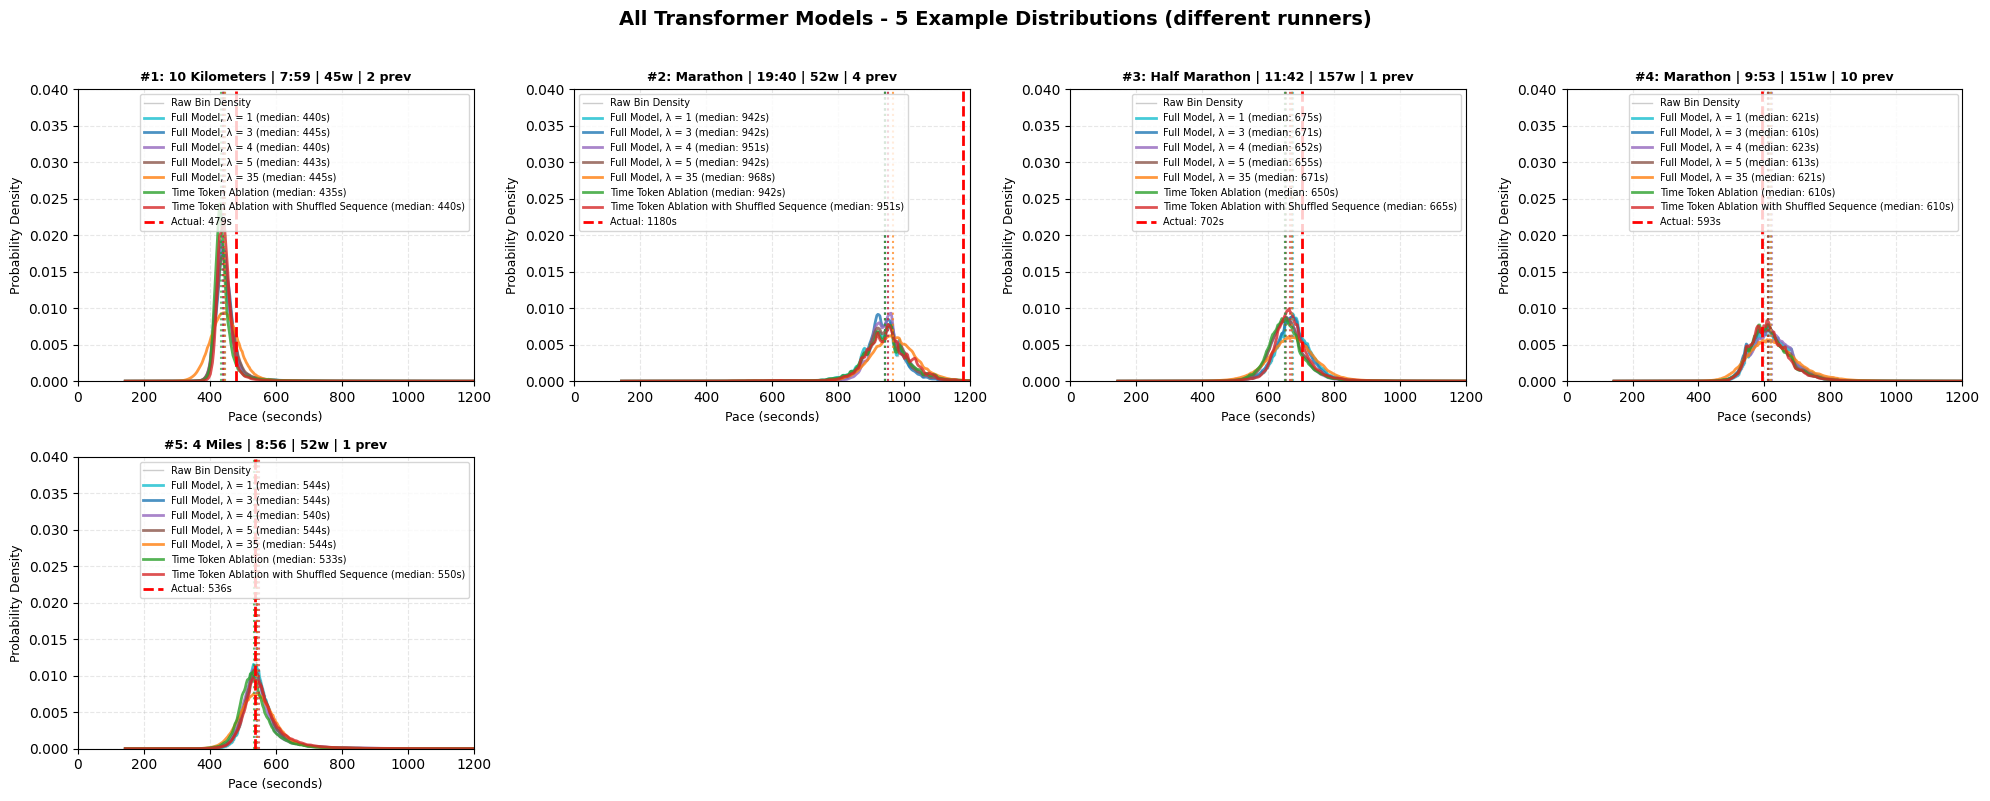

In [10]:
# Plot histogram-style probability distributions for 5 examples
# Style matched to Example_Runner_Trajectories (single model per subplot)
from runtime_inference import load_runners_from_splits

print("Loading 5 examples from different runners for histogram visualization...")
histogram_runners = load_runners_from_splits(
    max_runners=5,
    num_files=10,  # Just use first file for speed
    glob_pattern=TRAINING_SPLITS_GLOB,
    progress_interval=10
)

# Collect one example per runner (ensuring diversity)
histogram_examples = []
seen_runners_hist = set()  # Track runners we've used

for runner in histogram_runners:
    runner_id = id(runner)  # Use object id since RunnerForTraining is not hashable
    if runner_id in seen_runners_hist:
        continue
    
    # Find first valid example from this runner
    for ex in runner.training_examples:
        if len(ex.unpadded_example_sequence) >= 22:  # At least 1 prior race + 1 final race
            histogram_examples.append(ex)
            seen_runners_hist.add(runner_id)
            break
    
    if len(histogram_examples) >= 25:  # Stop when we have enough examples
        break

print(f"✓ Loaded {len(histogram_examples)} examples from {len(seen_runners_hist)} different runners\n")

# Prepare inference dicts for all transformer models
inferences_dict = {
    MODEL_NAME_1: inference_1,
    MODEL_NAME_2: inference_2,
    MODEL_NAME_3: inference_3,
    MODEL_NAME_4: inference_4,
    MODEL_NAME_5: inference_5,
    MODEL_NAME_6: inference_6,
    MODEL_NAME_7: inference_7,
}

print("Running inference for all transformer models on 5 example trajectories...")

n_examples = len(histogram_examples)
n_cols = min(4, n_examples)  # Max 4 columns
n_rows = (n_examples + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
fig.suptitle("All Transformer Models - 5 Example Distributions (different runners)", 
             fontsize=14, fontweight='bold', y=0.995)

# Flatten axes array for easier indexing
if n_examples == 1:
    axes_flat = [axes]
elif n_rows == 1:
    axes_flat = [axes] if n_cols == 1 else list(axes)
else:
    axes_flat = list(axes.flatten())

# Plot each example with all transformer models overlaid (one subplot per example)
for idx, ex in enumerate(histogram_examples):
    if idx < len(axes_flat):
        ax = axes_flat[idx]

        # Run inference for all models in standard plot order
        results_dict = {}
        for model_name in MODELS_PLOT_ORDER:
            if model_name in inferences_dict:
                inference_model = inferences_dict[model_name]
                results_dict[model_name] = inference_model.predict_from_raw_example(ex)

        # Use the multi-model helper (interpolated density, correct labels/colors)
        create_density_plot_multi_models(
            ex,
            results_dict=results_dict,
            inferences_dict=inferences_dict,
            example_num=idx + 1,
            ax=ax,
        )
    else:
        print(f"Warning: Skipping example {idx+1} - no subplot available")

# Hide unused subplots
for idx in range(n_examples, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.98])  # Leave space for suptitle
plt.show()


In [11]:
MAX_EXAMPLES = 10000


# Load runners and collect examples for MAE evaluation
# We need runners for XGBoost feature extraction
from runtime_inference import load_runners_from_splits, RunnerForTraining

print("Loading runners and collecting examples for MAE evaluation...")
mae_runners = load_runners_from_splits(
    num_files=None,  # Load from all available files
    glob_pattern=TRAINING_SPLITS_GLOB,
    progress_interval=10
)

# Collect examples with their runner references
mae_examples = []
mae_runners_list = []  # Parallel list to track which runner each example belongs to

for runner in mae_runners:
    for ex in runner.training_examples:
        if len(ex.unpadded_example_sequence) >= 22:  # At least 1 prior race + 1 final race
            mae_examples.append(ex)
            mae_runners_list.append(runner)
            if len(mae_examples) >= MAX_EXAMPLES:
                break
    if len(mae_examples) >= MAX_EXAMPLES:
        break

# Count unique runners (using id() since RunnerForTraining is not hashable)
unique_runner_ids = set(id(r) for r in mae_runners_list)
print(f"✓ Loaded {len(mae_examples)} examples from {len(unique_runner_ids)} runners\n")

# First, determine which examples XGBoost can successfully predict on
# Store predictions from first pass to avoid recomputing
xgb_successful_indices = []
xgb_predictions_cache = {}  # Cache predictions: {example_idx: prediction}

if xgb_booster and xgb_feature_columns:
    print(f"\n{'='*60}")
    print(f"Step 1: Running XGBoost predictions to identify valid examples...")
    print(f"{'='*60}")
    
    for i, (ex, runner) in enumerate(zip(mae_examples, mae_runners_list)):
        if (i + 1) % 200 == 0:
            print(f"  Processed {i + 1}/{len(mae_examples)} examples...")
        
        # Extract features and predict
        feats = extract_runner_features_full(runner, ex)
        if feats:
            pred_xgb = xgb_predict_from_feats(feats)
            if pred_xgb is not None:
                xgb_successful_indices.append(i)  # Track which example indices succeeded
                xgb_predictions_cache[i] = pred_xgb  # Cache the prediction
    
    print(f"✓ XGBoost: {len(xgb_successful_indices)} successful predictions out of {len(mae_examples)} examples")
    
    if len(xgb_successful_indices) == 0:
        print("⚠️  No XGBoost predictions generated. Will evaluate all models on all examples.")
        xgb_successful_indices = list(range(len(mae_examples)))  # Use all examples
    else:
        print(f"✓ Will evaluate all models on {len(xgb_successful_indices)} examples (where XGBoost succeeded)")
else:
    print("\n⚠️  XGBoost not available. Will evaluate transformer models on all examples.")
    xgb_successful_indices = list(range(len(mae_examples)))  # Use all examples

# Now evaluate all models (transformers + XGBoost) only on the examples where XGBoost succeeded
print(f"\n{'='*60}")
print(f"Step 2: Evaluating all models on {len(xgb_successful_indices)} examples (apples-to-apples comparison)")
print(f"{'='*60}")

# Initialize error storage for all transformer models
models = [
    (inference_1, MODEL_NAME_1),
    (inference_2, MODEL_NAME_2),
    (inference_3, MODEL_NAME_3),
    (inference_4, MODEL_NAME_4),
    (inference_5, MODEL_NAME_5),
    (inference_6, MODEL_NAME_6),
    (inference_7, MODEL_NAME_7)
]

results = {}
# Also store percentiles for calibration analysis
percentiles_by_model = {
    MODEL_NAME_1: [],
    MODEL_NAME_2: [],
    MODEL_NAME_3: [],
    MODEL_NAME_4: [],
    MODEL_NAME_5: [],
    MODEL_NAME_6: [],
    MODEL_NAME_7: []
}

for inference_model, model_name in models:
    print(f"\n{'='*60}")
    print(f"Running inference with {model_name}...")
    print(f"{'='*60}")
    
    errors_mean = []
    errors_median = []
    errors_mode = []
    percentiles = []  # Store percentiles for this model
    
    for idx, i in enumerate(xgb_successful_indices):
        ex = mae_examples[i]
        if (idx + 1) % 200 == 0:
            print(f"  Processed {idx + 1}/{len(xgb_successful_indices)} examples...")
        
        # Run inference
        result = inference_model.predict_from_raw_example(ex)
        
        # Compute absolute errors
        actual_pace = ex.actual_pace_seconds
        error_mean = abs(result['weighted_mean'] - actual_pace)
        error_median = abs(result['weighted_median'] - actual_pace)
        error_mode = abs(result['mode_pace'] - actual_pace)
        
        errors_mean.append(error_mean)
        errors_median.append(error_median)
        errors_mode.append(error_mode)
        
        # Compute percentile for calibration analysis
        percentile = compute_quantile(actual_pace, result, inference_model.pace_bins)
        percentiles.append(percentile)
    
    # Compute MAE and RMSE
    mae_mean = np.mean(errors_mean)
    mae_median = np.mean(errors_median)
    mae_mode = np.mean(errors_mode)
    
    rmse_mean = np.sqrt(np.mean([e**2 for e in errors_mean]))
    rmse_median = np.sqrt(np.mean([e**2 for e in errors_median]))
    rmse_mode = np.sqrt(np.mean([e**2 for e in errors_mode]))
    
    results[model_name] = {
        'mae_mean': mae_mean,
        'mae_median': mae_median,
        'mae_mode': mae_mode,
        'rmse_mean': rmse_mean,
        'rmse_median': rmse_median,
        'rmse_mode': rmse_mode,
        'errors_mean': errors_mean,
        'errors_median': errors_median,
        'errors_mode': errors_mode
    }
    
    # Store percentiles for calibration analysis
    percentiles_by_model[model_name] = percentiles

# Now compute XGBoost errors using cached predictions (no need to recompute)
if xgb_booster and xgb_feature_columns and xgb_predictions_cache:
    print(f"\n{'='*60}")
    print(f"Computing XGBoost errors from cached predictions ({len(xgb_successful_indices)} examples)...")
    print(f"{'='*60}")
    
    errors_xgb = []
    
    for idx, i in enumerate(xgb_successful_indices):
        ex = mae_examples[i]
        if i in xgb_predictions_cache:
            pred_xgb = xgb_predictions_cache[i]
            actual_pace = ex.actual_pace_seconds
            error_xgb = abs(pred_xgb - actual_pace)
            errors_xgb.append(error_xgb)
    
    if errors_xgb:
        mae_xgb = np.mean(errors_xgb)
        rmse_xgb = np.sqrt(np.mean([e**2 for e in errors_xgb]))
        
        results['XGBoost'] = {
            'mae_mean': mae_xgb,
            'mae_median': mae_xgb,  # XGBoost gives point predictions, so median = mean
            'mae_mode': mae_xgb,
            'rmse_mean': rmse_xgb,
            'rmse_median': rmse_xgb,
            'rmse_mode': rmse_xgb,
            'errors_mean': errors_xgb,
            'errors_median': errors_xgb,
            'errors_mode': errors_xgb,
            'successful_indices': xgb_successful_indices  # Store indices for alignment
        }
        print(f"✓ XGBoost: {len(errors_xgb)} successful predictions")
    else:
        print("⚠️  No XGBoost predictions generated")
else:
    print("\n⚠️  XGBoost not available, skipping XGBoost baseline")

# Print comparison table
# Note: model_labels, model_colors, and model_markers are defined in Cell 4
print(f"\n{'='*80}")
print("MODEL COMPARISON - MAE (Mean Absolute Error in seconds)")
print(f"{'='*80}")
print(f"{'Model':<50} {'Mean':<12} {'Median':<12} {'Mode':<12}")
print("-" * 100)
# Order: Lambda 1, 3, 4, 5, 35, then Ablation models
for model_name in MODELS_PLOT_ORDER:
    r = results[model_name]
    label = model_labels.get(model_name, model_name)
    print(f"{label:<50} {r['mae_mean']:<12.2f} {r['mae_median']:<12.2f} {r['mae_mode']:<12.2f}")
if 'XGBoost' in results:
    r = results['XGBoost']
    print(f"{'XGBoost':<50} {r['mae_mean']:<12.2f} {r['mae_median']:<12.2f} {r['mae_mode']:<12.2f}")

print(f"\n{'='*80}")
print("MODEL COMPARISON - RMSE (Root Mean Squared Error in seconds)")
print(f"{'='*80}")
print(f"{'Model':<50} {'Mean':<12} {'Median':<12} {'Mode':<12}")
print("-" * 100)
# Order: Lambda 1, 3, 4, 5, 35, then Ablation models
for model_name in MODELS_PLOT_ORDER:
    r = results[model_name]
    label = model_labels.get(model_name, model_name)
    print(f"{label:<50} {r['rmse_mean']:<12.2f} {r['rmse_median']:<12.2f} {r['rmse_mode']:<12.2f}")
if 'XGBoost' in results:
    r = results['XGBoost']
    print(f"{'XGBoost':<50} {r['rmse_mean']:<12.2f} {r['rmse_median']:<12.2f} {r['rmse_mode']:<12.2f}")

# Find best model for each metric
print(f"\n{'='*80}")
print("BEST MODEL BY METRIC")
print(f"{'='*80}")
best_mae_mean = min(results.items(), key=lambda x: x[1]['mae_mean'])
best_mae_median = min(results.items(), key=lambda x: x[1]['mae_median'])
best_mae_mode = min(results.items(), key=lambda x: x[1]['mae_mode'])
best_rmse_mean = min(results.items(), key=lambda x: x[1]['rmse_mean'])
best_rmse_median = min(results.items(), key=lambda x: x[1]['rmse_median'])
best_rmse_mode = min(results.items(), key=lambda x: x[1]['rmse_mode'])

print(f"Best MAE (Mean):   {model_labels.get(best_mae_mean[0], best_mae_mean[0])} ({best_mae_mean[1]['mae_mean']:.2f}s)")
print(f"Best MAE (Median): {model_labels.get(best_mae_median[0], best_mae_median[0])} ({best_mae_median[1]['mae_median']:.2f}s)")
print(f"Best MAE (Mode):   {model_labels.get(best_mae_mode[0], best_mae_mode[0])} ({best_mae_mode[1]['mae_mode']:.2f}s)")
print(f"Best RMSE (Mean):  {model_labels.get(best_rmse_mean[0], best_rmse_mean[0])} ({best_rmse_mean[1]['rmse_mean']:.2f}s)")
print(f"Best RMSE (Median): {model_labels.get(best_rmse_median[0], best_rmse_median[0])} ({best_rmse_median[1]['rmse_median']:.2f}s)")
print(f"Best RMSE (Mode):  {model_labels.get(best_rmse_mode[0], best_rmse_mode[0])} ({best_rmse_mode[1]['rmse_mode']:.2f}s)")

print(f"\nSample size: {len(mae_examples)} examples")


Loading runners and collecting examples for MAE evaluation...
  Processed 10/10 files...
✓ Loaded 59450 runners from 10 files
✓ Loaded 10000 examples from 1135 runners


Step 1: Running XGBoost predictions to identify valid examples...
  Processed 200/10000 examples...
  Processed 400/10000 examples...
  Processed 600/10000 examples...
  Processed 800/10000 examples...
  Processed 1000/10000 examples...
  Processed 1200/10000 examples...
  Processed 1400/10000 examples...
  Processed 1600/10000 examples...
  Processed 1800/10000 examples...
  Processed 2000/10000 examples...
  Processed 2200/10000 examples...
  Processed 2400/10000 examples...
  Processed 2600/10000 examples...
  Processed 2800/10000 examples...
  Processed 3000/10000 examples...
  Processed 3200/10000 examples...
  Processed 3400/10000 examples...
  Processed 3600/10000 examples...
  Processed 3800/10000 examples...
  Processed 4000/10000 examples...
  Processed 4200/10000 examples...
  Processed 4400/10000 examples..

In [12]:
# --- SAVE COMPUTED RESULTS TO DISK ---
# Save all computed values so downstream cells can load them without re-running

import pickle
from pathlib import Path

# Define save path (in data directory, similar to pace_lookup.pickle)
SAVE_DIR = Path("/Users/yaelelmatad/Desktop/nyrr-transform/Runtime/data")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
SAVE_PATH = SAVE_DIR / "mae_evaluation_results.pickle"

print(f"Saving computed results to: {SAVE_PATH}")
print("="*80)

# Prepare data dictionary with all necessary information
save_data = {
    # Raw data
    'mae_examples': mae_examples,
    'mae_runners_list': mae_runners_list,
    
    # XGBoost filtering
    'xgb_successful_indices': xgb_successful_indices,
    'xgb_predictions_cache': xgb_predictions_cache,
    
    # Model results (MAE/RMSE for all models, including XGBoost if available)
    'results': results,  # Contains results for all 7 transformer models + 'XGBoost' (if computed)
    
    # Calibration data
    'percentiles_by_model': percentiles_by_model,
    
    # Model names for reference
    'model_names': {
        'MODEL_NAME_1': MODEL_NAME_1,
        'MODEL_NAME_2': MODEL_NAME_2,
        'MODEL_NAME_3': MODEL_NAME_3,
        'MODEL_NAME_4': MODEL_NAME_4,
        'MODEL_NAME_5': MODEL_NAME_5,
        'MODEL_NAME_6': MODEL_NAME_6,
        'MODEL_NAME_7': MODEL_NAME_7,
    },
    
    # Metadata
    'max_examples': MAX_EXAMPLES,
    'num_examples_loaded': len(mae_examples),
    'num_xgb_successful': len(xgb_successful_indices),
}

# Save to disk
with open(SAVE_PATH, 'wb') as f:
    pickle.dump(save_data, f)

print(f"✓ Saved {len(mae_examples)} examples")
print(f"✓ Saved {len(xgb_successful_indices)} XGBoost-successful indices")
print(f"✓ Saved results for {len(results)} models", end="")
if 'XGBoost' in results:
    print(" (including XGBoost)")
else:
    print(" (XGBoost not computed)")
print(f"✓ Saved percentiles for {len(percentiles_by_model)} models")
print(f"\nFile size: {SAVE_PATH.stat().st_size / (1024*1024):.2f} MB")
print(f"\nSaved data structure:")
print(f"  - mae_examples: {len(save_data['mae_examples'])} examples")
print(f"  - mae_runners_list: {len(save_data['mae_runners_list'])} runners")
print(f"  - xgb_successful_indices: {len(save_data['xgb_successful_indices'])} indices")
print(f"  - xgb_predictions_cache: {len(save_data['xgb_predictions_cache'])} cached predictions")
print(f"  - results: {list(save_data['results'].keys())}")
if 'XGBoost' in save_data['results']:
    print(f"    → XGBoost results included: MAE={save_data['results']['XGBoost']['mae_mean']:.2f}s, RMSE={save_data['results']['XGBoost']['rmse_mean']:.2f}s")
print(f"  - percentiles_by_model: {list(save_data['percentiles_by_model'].keys())}")
print(f"\n✓ Data saved successfully!")
print("="*80)


Saving computed results to: /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/data/mae_evaluation_results.pickle


✓ Saved 10000 examples
✓ Saved 9803 XGBoost-successful indices
✓ Saved results for 8 models (including XGBoost)
✓ Saved percentiles for 7 models

File size: 20.50 MB

Saved data structure:
  - mae_examples: 10000 examples
  - mae_runners_list: 10000 runners
  - xgb_successful_indices: 9803 indices
  - xgb_predictions_cache: 9803 cached predictions
  - results: ['SwappedOrder', 'Ablation', 'AblationShuffled', 'SwappedOrder_Lambda1', 'SwappedOrder_Lambda35', 'SwappedOrder_Lambda4', 'SwappedOrder_Lambda5', 'XGBoost']
    → XGBoost results included: MAE=42.59s, RMSE=81.01s
  - percentiles_by_model: ['SwappedOrder', 'Ablation', 'AblationShuffled', 'SwappedOrder_Lambda1', 'SwappedOrder_Lambda35', 'SwappedOrder_Lambda4', 'SwappedOrder_Lambda5']

✓ Data saved successfully!


In [13]:
# Verification: Compare XGBoost setup with Inspect_Model_Outputs.ipynb
print("="*80)
print("XGBOOST LOADING VERIFICATION")
print("="*80)

# Check 1: Model path
print(f"\n1. Model Path:")
print(f"   Current notebook: {XGB_MODEL_PATH}")
print(f"   Inspect_Model_Outputs uses: xgb_first_10_continuous")
print(f"   Note: Using xgb_first_50_continuous (different version)")

# Check 2: Loading method
print(f"\n2. Loading Method:")
print(f"   xgb_booster type: {type(xgb_booster) if xgb_booster else 'None'}")
if xgb_booster:
    print(f"   ✓ Loaded using: xgb.Booster() and load_model()")
    print(f"   Model file exists: {os.path.exists(XGB_MODEL_PATH)}")
else:
    print(f"   ⚠️  XGBoost booster not loaded")

# Check 3: Feature columns
print(f"\n3. Feature Columns:")
if xgb_feature_columns:
    print(f"   ✓ Feature columns loaded: {len(xgb_feature_columns)} columns")
    print(f"   First 5 columns: {xgb_feature_columns[:5]}")
    print(f"   Last 5 columns: {xgb_feature_columns[-5:]}")
else:
    print(f"   ⚠️  Feature columns not loaded")

# Check 4: Functions match
print(f"\n4. Function Verification:")
print(f"   extract_runner_features_full defined: {'extract_runner_features_full' in globals()}")
print(f"   xgb_predict_from_feats defined: {'xgb_predict_from_feats' in globals()}")
print(f"   DISTANCE_MAP defined: {'DISTANCE_MAP' in globals()}")

# Check 5: Test prediction on a sample example
if xgb_booster and xgb_feature_columns and len(mae_examples) > 0:
    print(f"\n5. Test Prediction:")
    test_ex = mae_examples[0]
    test_runner = mae_runners_list[0]
    
    # Extract features
    feats = extract_runner_features_full(test_runner, test_ex)
    if feats:
        print(f"   ✓ Features extracted successfully")
        print(f"   Features keys: {list(feats.keys())}")
        
        # Make prediction
        pred = xgb_predict_from_feats(feats)
        if pred is not None:
            actual = test_ex.actual_pace_seconds
            error = abs(pred - actual)
            print(f"   ✓ Prediction successful")
            print(f"   Predicted: {pred:.2f}s ({pred/60:.1f} min)")
            print(f"   Actual: {actual:.2f}s ({actual/60:.1f} min)")
            print(f"   Error: {error:.2f}s")
        else:
            print(f"   ⚠️  Prediction returned None")
    else:
        print(f"   ⚠️  Feature extraction returned None")
        print(f"   Example sequence length: {len(test_ex.unpadded_example_sequence)}")
        print(f"   Raw pace data length: {len(test_ex.raw_pace_data) if test_ex.raw_pace_data else 0}")

# Summary
print(f"\n{'='*80}")
print("SUMMARY")
print(f"{'='*80}")
print("✓ Loading method: IDENTICAL (xgb.Booster() and load_model())")
print("✓ Feature extraction: IDENTICAL (extract_runner_features_full)")
print("✓ Prediction function: IDENTICAL (xgb_predict_from_feats)")
print("⚠️  Model version: DIFFERENT (xgb_first_50_continuous vs xgb_first_10_continuous)")
print("\nAll XGBoost components match except model version.")
print(f"\n{'='*80}")
print("VERIFICATION COMPLETE")
print(f"{'='*80}")


XGBOOST LOADING VERIFICATION

1. Model Path:
   Current notebook: /Users/yaelelmatad/Desktop/nyrr-transform/Runtime/train/xgb_first_50_continuous/xgboost_model.json
   Inspect_Model_Outputs uses: xgb_first_10_continuous
   Note: Using xgb_first_50_continuous (different version)

2. Loading Method:
   xgb_booster type: <class 'xgboost.core.Booster'>
   ✓ Loaded using: xgb.Booster() and load_model()
   Model file exists: True

3. Feature Columns:
   ✓ Feature columns loaded: 27 columns
   First 5 columns: ['avg_historical_pace', 'last_pace', 'ema_historical_pace', 'min_historical_pace', 'max_historical_pace']
   Last 5 columns: ['conditions_vc_conditions_clear', 'conditions_vc_conditions_overcast', 'conditions_vc_conditions_partially_cloudy', 'conditions_vc_conditions_rain', 'conditions_vc_conditions_snow']

4. Function Verification:
   extract_runner_features_full defined: True
   xgb_predict_from_feats defined: True
   DISTANCE_MAP defined: True

5. Test Prediction:
   ✓ Features extra

Grouping MAE data by history length with bucketing (reusing data from previous cell)...
✓ Using 10000 examples from previous cell

  Using 9803 examples (where XGBoost succeeded) for apples-to-apples comparison
✓ Grouped errors by history length and bucketed



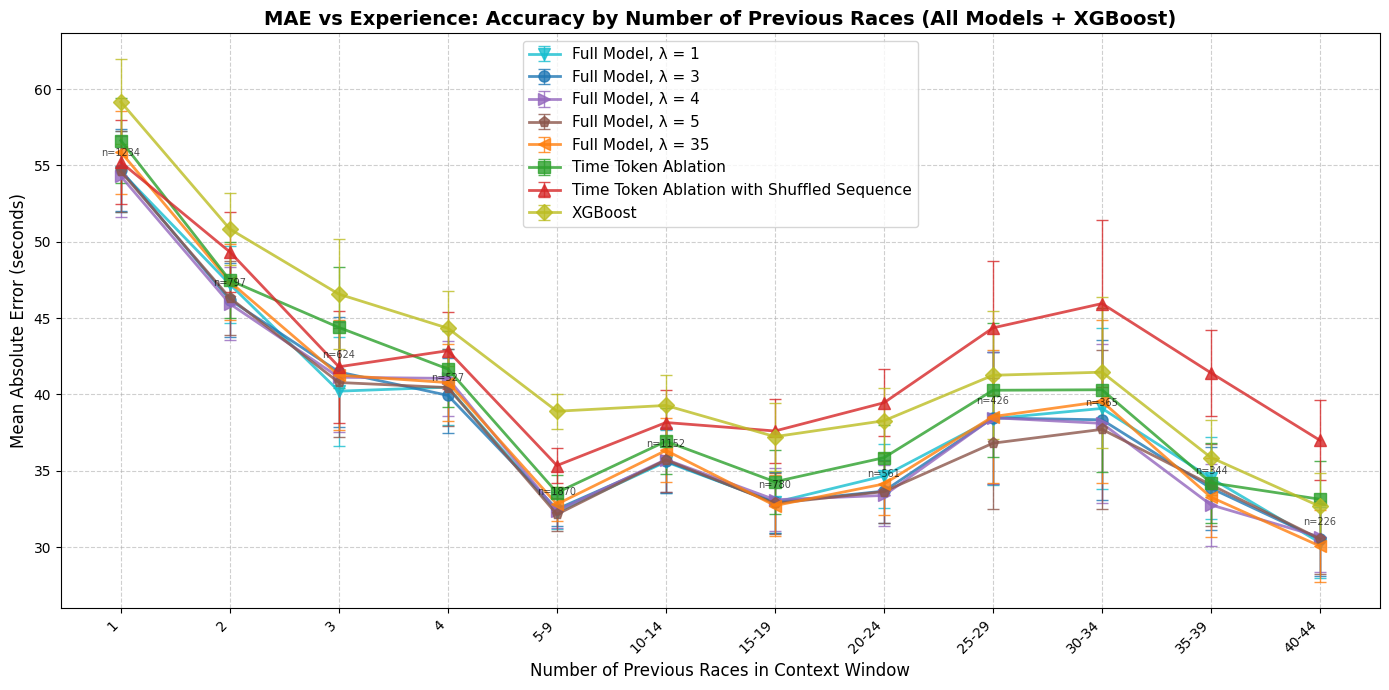


MAE BY HISTORY LENGTH (BUCKETED - showing buckets with at least 5 examples)
Bucket       Samples    Full Model, λ = 1                   Full Model, λ = 3                   Full Model, λ = 4                   Full Model, λ = 5                   Full Model, λ = 35                  Time Token Ablation                 Time Token Ablation with Shuffled Sequence XGBoost                            
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1            1234       54.59                               54.69                               54.29                               54.60                               55.87                               56.63                               55.21                               59.15    

In [14]:
# Compute MAE grouped by number of previous races for all 3 models
# Reuse the data from the previous MAE comparison cell instead of making new predictions
from collections import defaultdict

def bucket_history_length(h, max_history=44):
    """Bucket history lengths: 1-4 individual, then 5-9, 10-14, 15-19, etc. Capped at max_history."""
    if h > max_history:
        return None  # Exclude history lengths beyond max
    if h <= 4:
        return h  # Individual buckets for 1, 2, 3, 4
    else:
        # Group into ranges: 5-9, 10-14, 15-19, 20-24, 25-29, 30-34, 35-39, 40
        bucket_start = ((h - 5) // 5) * 5 + 5
        bucket_end = min(bucket_start + 4, max_history)
        if bucket_start == bucket_end:
            return bucket_start  # Single value if at max
        return f"{bucket_start}-{bucket_end}"

def get_bucket_label(bucket):
    """Get display label for a bucket."""
    if isinstance(bucket, int):
        return str(bucket)
    return bucket

def get_bucket_sort_key(bucket):
    """Get a sort key for a bucket to ensure proper numerical ordering."""
    if isinstance(bucket, int):
        return bucket
    # For string buckets like "5-9", use the start value
    return int(bucket.split('-')[0])

print("Grouping MAE data by history length with bucketing (reusing data from previous cell)...")

# Check if we have the data from the previous cell
if 'mae_examples' not in globals() or 'results' not in globals():
    print("❌ ERROR: Please run the MAE comparison cell (Step 7) first!")
    print("   The history length analysis requires the data from that cell.")
else:
    print(f"✓ Using {len(mae_examples)} examples from previous cell\n")
    
    # Track errors by history length (unbucketed) for each model
    results_by_history_raw = defaultdict(lambda: {
        MODEL_NAME_1: [],
        MODEL_NAME_2: [],
        MODEL_NAME_3: [],
        MODEL_NAME_4: [],
        MODEL_NAME_5: [],
        MODEL_NAME_6: [],
        MODEL_NAME_7: [],
        'XGBoost': []
    })
    
    # Also track week_delta for each example (to avoid recomputing later)
    example_week_deltas = {}  # {example_idx: week_delta}
    
    # Helper function to extract week_delta from sequence
    def extract_week_delta_from_sequence(seq, block_stride=11):
        """Extract the week_delta_to_final token from the last historical race block."""
        num_races = len(seq) // block_stride
        if num_races < 2:
            return None
        last_hist_block_start = (num_races - 2) * block_stride
        week_delta_token = seq[last_hist_block_start + 8]  # week_delta_to_final is at position 8
        if week_delta_token.startswith('week_delta_'):
            try:
                return int(week_delta_token.split('_')[-1])
            except (ValueError, IndexError):
                return None
        return None
    
    # Group the already-computed errors by history length
    # All models are now evaluated on the same subset of examples (where XGBoost succeeded)
    # Get the successful indices from XGBoost results, or use all examples if XGBoost not available
    if 'XGBoost' in results and 'successful_indices' in results['XGBoost']:
        valid_indices = results['XGBoost']['successful_indices']
        print(f"  Using {len(valid_indices)} examples (where XGBoost succeeded) for apples-to-apples comparison")
    else:
        # If XGBoost not available, all models were evaluated on all examples
        valid_indices = list(range(len(mae_examples)))
        print(f"  Using all {len(valid_indices)} examples (XGBoost not available)")
    
    # Group errors by history length for all models (unbucketed)
    # Also extract week_delta while we're at it
    for error_idx, example_idx in enumerate(valid_indices):
        if example_idx >= len(mae_examples):
            continue
            
        ex = mae_examples[example_idx]
        # Calculate number of previous races from original sequence
        seq_len = len(ex.unpadded_example_sequence)
        block_stride = 11  # Original sequence always uses 11 tokens per race
        num_races = seq_len // block_stride
        num_prev_races = num_races - 1  # Exclude the final race
        
        if num_prev_races < 1:
            continue
        
        # Extract week_delta once and store it
        week_delta = extract_week_delta_from_sequence(ex.unpadded_example_sequence, block_stride)
        if week_delta is not None:
            example_week_deltas[example_idx] = week_delta
        
        # All models are evaluated on the same examples, so errors are aligned by error_idx
        # Order: Lambda 1, 3, 4, 5, 35, then Ablation models
        for model_name in [MODEL_NAME_4, MODEL_NAME_1, MODEL_NAME_6, MODEL_NAME_7, MODEL_NAME_5, MODEL_NAME_2, MODEL_NAME_3, 'XGBoost']:
            if model_name in results and 'errors_median' in results[model_name]:
                if error_idx < len(results[model_name]['errors_median']):
                    error = results[model_name]['errors_median'][error_idx]
                    results_by_history_raw[num_prev_races][model_name].append(error)
    
    # Now bucket the results
    results_by_history = defaultdict(lambda: {
        MODEL_NAME_1: [],
        MODEL_NAME_2: [],
        MODEL_NAME_3: [],
        MODEL_NAME_4: [],
        MODEL_NAME_5: [],
        MODEL_NAME_6: [],
        MODEL_NAME_7: [],
        'XGBoost': []
    })
    
    # Aggregate errors by bucket (only up to max_history=44)
    for h in results_by_history_raw.keys():
        bucket = bucket_history_length(h, max_history=44)
        if bucket is None:  # Skip history lengths beyond max
            continue
        # Order: Lambda 1, 3, 4, 5, 35, then Ablation models
        for model_name in [MODEL_NAME_4, MODEL_NAME_1, MODEL_NAME_6, MODEL_NAME_7, MODEL_NAME_5, MODEL_NAME_2, MODEL_NAME_3, 'XGBoost']:
            if model_name in results_by_history_raw[h]:
                results_by_history[bucket][model_name].extend(results_by_history_raw[h][model_name])
    
    print(f"✓ Grouped errors by history length and bucketed\n")
    
    # Get sorted bucket labels for plotting
    # Sort all buckets using a unified sort key to ensure proper numerical ordering
    all_buckets = list(results_by_history.keys())
    history_lengths = sorted(all_buckets, key=get_bucket_sort_key)
    
    plt.figure(figsize=(14, 7))
    
    
    # Note: model_labels, model_colors, and model_markers are defined in Cell 4
    
    # Plot each model
    # Order: Lambda 1, 3, 4, 5, then Ablation models
    models_to_plot = list(MODELS_PLOT_ORDER)  # copy to avoid mutating global list
    if 'XGBoost' in results:
        models_to_plot.append('XGBoost')
    
    # Create mapping from bucket to x-axis position
    bucket_to_pos = {bucket: i for i, bucket in enumerate(history_lengths)}
    
    for model_name in models_to_plot:
        # Only include buckets with at least 5 examples
        valid_buckets = [b for b in history_lengths if len(results_by_history[b][model_name]) >= 5]
        valid_positions = [bucket_to_pos[b] for b in valid_buckets]
        maes = [np.mean(results_by_history[b][model_name]) for b in valid_buckets]
        # Calculate Standard Error of the Mean (SEM)
        sems = [np.std(results_by_history[b][model_name]) / np.sqrt(len(results_by_history[b][model_name])) 
                for b in valid_buckets]
        
        color = model_colors.get(model_name, 'gray')
        marker = model_markers.get(model_name, 'o')
        label = model_labels.get(model_name, model_name)
        
        # Debug: Verify lookup worked (should not use fallback for MODEL_NAME_5)
        if model_name == MODEL_NAME_5 and label == model_name:
            print(f"⚠️  Warning: Lookup failed for {model_name}. Available keys: {list(model_labels.keys())}")
        
        plt.errorbar(valid_positions, maes, yerr=sems, marker=marker, label=label,
                     color=color, linewidth=2, markersize=8, capsize=4, elinewidth=1, alpha=0.8)
        
        # Annotate sample sizes for first model
        if model_name == MODEL_NAME_1:
            for pos, bucket, val in zip(valid_positions, valid_buckets, maes):
                n_samples = len(results_by_history[bucket][model_name])
                plt.annotate(f'n={n_samples}', (pos, val), textcoords="offset points", 
                            xytext=(0, 10), ha='center', fontsize=7, alpha=0.7)
    
    title = 'MAE vs Experience: Accuracy by Number of Previous Races'
    if 'XGBoost' in results:
        title += ' (All Models + XGBoost)'
    else:
        title += ' (All 3 Models)'
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Number of Previous Races in Context Window', fontsize=12)
    plt.ylabel('Mean Absolute Error (seconds)', fontsize=12)
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    # Set x-axis labels
    bucket_labels = [get_bucket_label(b) for b in history_lengths]
    plt.xticks(range(len(history_lengths)), bucket_labels, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*80}")
    print("MAE BY HISTORY LENGTH (BUCKETED - showing buckets with at least 5 examples)")
    print(f"{'='*80}")
    # Order: Lambda 1, 3, 4, 5, then Ablation models
    header_models = list(MODELS_PLOT_ORDER)  # copy to avoid mutating global list
    if 'XGBoost' in results:
        header_models.append('XGBoost')
    # Use model_labels for display names
    header_labels = [model_labels.get(m, m) for m in header_models]
    header = f"{'Bucket':<12} {'Samples':<10} " + " ".join([f"{m:<35}" for m in header_labels])
    print(header)
    print("-" * len(header))
    for bucket in history_lengths:
        counts = [len(results_by_history[bucket][m]) for m in header_models]
        if max(counts) >= 5:
            # All models should have the same count (apples-to-apples), use max to be safe
            sample_count = max(counts)
            maes = [np.mean(results_by_history[bucket][m]) if len(results_by_history[bucket][m]) >= 5 else np.nan
                    for m in header_models]
            maes_str = " ".join([f"{m:<35.2f}" for m in maes])
            bucket_label = get_bucket_label(bucket)
            print(f"{bucket_label:<12} {sample_count:<10} {maes_str}")


Computing relative performance (MAE / SwappedOrder MAE) with bucketing...

✓ Models being compared (relative to SwappedOrder baseline):
   - SwappedOrder_Lambda1
   - SwappedOrder_Lambda4
   - SwappedOrder_Lambda5
   - SwappedOrder_Lambda35
   - Ablation
   - AblationShuffled
   - XGBoost


PLOTTING RELATIVE PERFORMANCE FOR 7 MODELS:
  - SwappedOrder_Lambda1: 12 buckets with data
  - SwappedOrder_Lambda4: 12 buckets with data
  - SwappedOrder_Lambda5: 12 buckets with data
  - SwappedOrder_Lambda35: 12 buckets with data
  - Ablation: 12 buckets with data
  - AblationShuffled: 12 buckets with data
  - XGBoost: 12 buckets with data



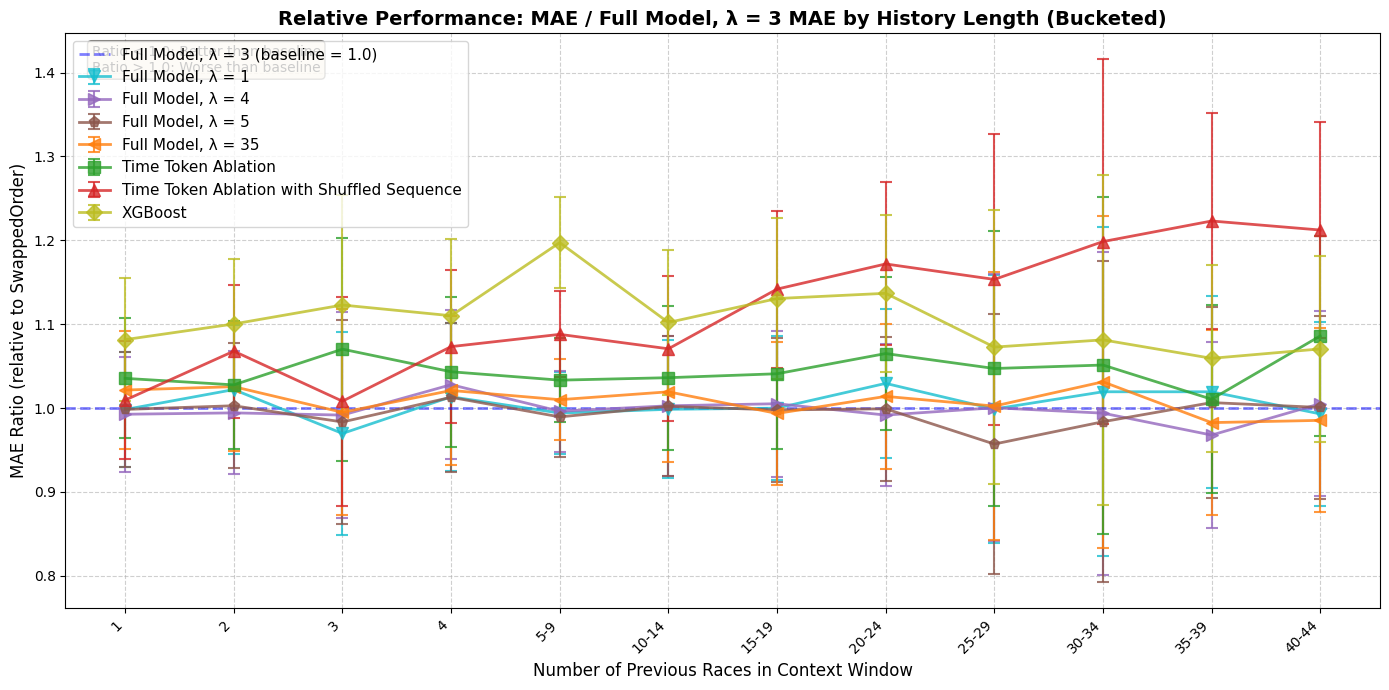


RELATIVE PERFORMANCE (MAE / SwappedOrder MAE) - BUCKETED
Bucket       Samples    Full Model, λ = 1    Full Model, λ = 4    Full Model, λ = 5    Full Model, λ = 35   Time Token Ablation  Time Token Ablation with Shuffled Sequence XGBoost             
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1            1234       0.998                0.993                0.998                1.021                1.035                1.009                1.082               
2            797        1.022                0.994                1.003                1.026                1.028                1.068                1.100               
3            624        0.970                0.992                0.983                0.995                1.070                1.008                1.123               
4            527        1.013              

In [15]:
# Plot relative performance: MAE / SwappedOrder MAE as a function of history length
# This shows how much better/worse each model is compared to SwappedOrder baseline

# Define bucketing functions (in case Cell 20 wasn't run)
def bucket_history_length(h, max_history=44):
    """Bucket history lengths: 1-4 individual, then 5-9, 10-14, 15-19, etc. Capped at max_history."""
    if h > max_history:
        return None  # Exclude history lengths beyond max
    if h <= 4:
        return h  # Individual buckets for 1, 2, 3, 4
    else:
        # Group into ranges: 5-9, 10-14, 15-19, 20-24, 25-29, 30-34, 35-39, 40
        bucket_start = ((h - 5) // 5) * 5 + 5
        bucket_end = min(bucket_start + 4, max_history)
        if bucket_start == bucket_end:
            return bucket_start  # Single value if at max
        return f"{bucket_start}-{bucket_end}"

def get_bucket_label(bucket):
    """Get display label for a bucket."""
    if isinstance(bucket, int):
        return str(bucket)
    return bucket

def get_bucket_sort_key(bucket):
    """Get a sort key for a bucket to ensure proper numerical ordering."""
    if isinstance(bucket, int):
        return bucket
    # For string buckets like "5-9", use the start value
    return int(bucket.split('-')[0])

print("Computing relative performance (MAE / SwappedOrder MAE) with bucketing...")

# Check if we have the data from the previous cell
# Try to access results_by_history - it should exist if Step 8 was run
try:
    # Directly try to access the variable
    test_access = results_by_history
    # Check what keys are actually available
    if len(test_access) == 0:
        raise ValueError("results_by_history is empty")
    
    # results_by_history is keyed by bucket (int for 1-4, string for ranges like "5-9")
    # Find buckets that have data to check available models (filter to max 40)
    all_buckets = list(test_access.keys())
    # Filter buckets to max 40 and sort using unified sort key
    filtered_buckets = []
    for b in all_buckets:
        if isinstance(b, int):
            if b <= 40:
                filtered_buckets.append(b)
        else:
            # String bucket like "5-9"
            bucket_start = int(b.split('-')[0])
            if bucket_start <= 40:
                filtered_buckets.append(b)
    history_lengths = sorted(filtered_buckets, key=get_bucket_sort_key)
    
    if len(history_lengths) == 0:
        raise ValueError("No buckets found in results_by_history")
    
    # Check what models are available in the first bucket with data
    available_models = []
    for bucket in history_lengths:
        if len(test_access[bucket]) > 0:
            available_models = list(test_access[bucket].keys())
            break
    
    if len(available_models) == 0:
        raise ValueError("No models found in results_by_history")
    
    # Find the baseline model - use MODEL_NAME_1 if available
    if MODEL_NAME_1 in available_models:
        baseline_model = MODEL_NAME_1  # SwappedOrder
    else:
        # Fallback: use first available model as baseline
        baseline_model = available_models[0]
        print(f"⚠️  Warning: {MODEL_NAME_1} not found in results_by_history.")
        print(f"   Using {baseline_model} as baseline instead.")
        print(f"   Available models: {available_models}")
except NameError:
    print("❌ ERROR: Please run the MAE vs history length cell (Step 8) first!")
    print("   Variable 'results_by_history' not found.")
except (KeyError, ValueError) as e:
    print("❌ ERROR: Please run the MAE vs history length cell (Step 8) first!")
    print(f"   {e}")
    if 'test_access' in locals() and len(test_access) > 0:
        # Show sample of what's in results_by_history
        sample_h = list(test_access.keys())[0]
        print(f"   Sample history length {sample_h} contains: {list(test_access[sample_h].keys())}")
else:
    
    # Models to compare (exclude baseline itself)
    models_to_compare = []
    # Add models that exist in results_by_history, excluding the baseline
    # Order: Lambda 1, 4, 5, 35, then Ablation models (baseline MODEL_NAME_1 is excluded)
    for model_name in [MODEL_NAME_4, MODEL_NAME_6, MODEL_NAME_7, MODEL_NAME_5, MODEL_NAME_2, MODEL_NAME_3, 'XGBoost']:
        # Check if this model has data in results_by_history
        has_data = False
        for h in history_lengths:
            if model_name in results_by_history[h] and len(results_by_history[h][model_name]) > 0:
                has_data = True
                break
        if has_data and model_name != baseline_model:
            models_to_compare.append(model_name)
    
    # Print which models are being compared
    print(f"\n✓ Models being compared (relative to {baseline_model} baseline):")
    for model_name in models_to_compare:
        print(f"   - {model_name}")
    if len(models_to_compare) == 0:
        print("   ⚠️  No models found in results_by_history!")
    print()
    
    # Compute ratios for each model (using bucketed data)
    ratios_by_model = {}
    valid_buckets = []
    
    for bucket in history_lengths:
        # Check if baseline has enough data
        if len(results_by_history[bucket][baseline_model]) < 5:
            continue
        
        baseline_mae = np.mean(results_by_history[bucket][baseline_model])
        if baseline_mae == 0:
            continue  # Skip if baseline MAE is zero (shouldn't happen)
        
        valid_buckets.append(bucket)
        
        for model_name in models_to_compare:
            if model_name not in results_by_history[bucket] or len(results_by_history[bucket][model_name]) < 5:
                continue
            
            model_mae = np.mean(results_by_history[bucket][model_name])
            ratio = model_mae / baseline_mae
            
            if model_name not in ratios_by_model:
                ratios_by_model[model_name] = []
            ratios_by_model[model_name].append(ratio)
    
    # Plot the ratios
    plt.figure(figsize=(14, 7))
    
    
    # Note: model_labels, model_colors, and model_markers are defined in Cell 4
    
    # Create mapping from bucket to x-axis position
    bucket_to_pos = {bucket: i for i, bucket in enumerate(valid_buckets)}
    
    # Print summary of what will be plotted
    print(f"\n{'='*80}")
    print(f"PLOTTING RELATIVE PERFORMANCE FOR {len(models_to_compare)} MODELS:")
    for model_name in models_to_compare:
        num_buckets = len(ratios_by_model.get(model_name, []))
        print(f"  - {model_name}: {num_buckets} buckets with data")
    print(f"{'='*80}\n")
    
    # Plot each model's ratio with error bars
    for model_name in models_to_compare:
        if model_name not in ratios_by_model or len(ratios_by_model[model_name]) == 0:
            continue
        
        # Get valid buckets for this model
        model_valid_buckets = []
        model_valid_positions = []
        model_ratios = []
        model_ratio_errors = []  # Error bars for ratios
        
        for bucket in valid_buckets:
            if len(results_by_history[bucket][baseline_model]) < 5:
                continue
            if model_name not in results_by_history[bucket] or len(results_by_history[bucket][model_name]) < 5:
                continue
            
            # Compute means and standard errors
            baseline_errors = results_by_history[bucket][baseline_model]
            model_errors = results_by_history[bucket][model_name]
            
            baseline_mae = np.mean(baseline_errors)
            model_mae = np.mean(model_errors)
            ratio = model_mae / baseline_mae
            
            # Compute standard errors of the mean
            baseline_sem = np.std(baseline_errors, ddof=1) / np.sqrt(len(baseline_errors))
            model_sem = np.std(model_errors, ddof=1) / np.sqrt(len(model_errors))
            
            # Error propagation for ratio R = A/B:
            # δR/R ≈ sqrt((δA/A)² + (δB/B)²)
            # So δR = R * sqrt((sem_A/A)² + (sem_B/B)²)
            relative_error = np.sqrt((model_sem / model_mae)**2 + (baseline_sem / baseline_mae)**2)
            ratio_error = ratio * relative_error
            
            model_valid_buckets.append(bucket)
            model_valid_positions.append(bucket_to_pos[bucket])
            model_ratios.append(ratio)
            model_ratio_errors.append(ratio_error)
        
        if len(model_valid_positions) > 0:
            color = model_colors.get(model_name, 'gray')
            marker = model_markers.get(model_name, 'o')
            
            # Use errorbar instead of plot to show error bars
            label = model_labels.get(model_name, model_name)
            plt.errorbar(model_valid_positions, model_ratios, yerr=model_ratio_errors,
                        marker=marker, label=label,
                        color=color, linewidth=2, markersize=8, alpha=0.8,
                        capsize=4, capthick=1.5, elinewidth=1.5)
    
    # Add horizontal line at 1.0 (baseline)
    baseline_label = model_labels.get(baseline_model, baseline_model)
    plt.axhline(1.0, color='blue', linestyle='--', linewidth=2, alpha=0.5, label=f'{baseline_label} (baseline = 1.0)')
    
    plt.title(f'Relative Performance: MAE / {baseline_label} MAE by History Length (Bucketed)', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Number of Previous Races in Context Window', fontsize=12)
    plt.ylabel(f'MAE Ratio (relative to {baseline_model})', fontsize=12)
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    # Set x-axis labels
    bucket_labels = [get_bucket_label(b) for b in valid_buckets]
    plt.xticks(range(len(valid_buckets)), bucket_labels, rotation=45, ha='right')
    
    # Add text annotation explaining the plot
    plt.text(0.02, 0.98, 
             'Ratio < 1.0: Better than baseline\nRatio > 1.0: Worse than baseline',
             transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print(f"\n{'='*80}")
    print(f"RELATIVE PERFORMANCE (MAE / {baseline_model} MAE) - BUCKETED")
    print(f"{'='*80}")
    # Use display labels from model_labels for header
    header_labels = [model_labels.get(m, m) for m in models_to_compare]
    header = f"{'Bucket':<12} {'Samples':<10} " + " ".join([f"{m:<20}" for m in header_labels])
    print(header)
    print("-" * len(header))
    
    for bucket in valid_buckets:
        if len(results_by_history[bucket][baseline_model]) < 5:
            continue
        
        baseline_mae = np.mean(results_by_history[bucket][baseline_model])
        sample_count = len(results_by_history[bucket][baseline_model])
        
        ratios = []
        for model_name in models_to_compare:
            if model_name in results_by_history[bucket] and len(results_by_history[bucket][model_name]) >= 5:
                model_mae = np.mean(results_by_history[bucket][model_name])
                ratio = model_mae / baseline_mae
                ratios.append(f"{ratio:<20.3f}")
            else:
                ratios.append(f"{'N/A':<20}")
        
        ratios_str = " ".join(ratios)
        bucket_label = get_bucket_label(bucket)
        print(f"{bucket_label:<12} {sample_count:<10} {ratios_str}")


Grouping MAE data by week gap between last race and final race...
✓ Using week_delta data computed in Step 8

  Using 9803 examples (where XGBoost succeeded) for apples-to-apples comparison
✓ Grouped errors by week gap



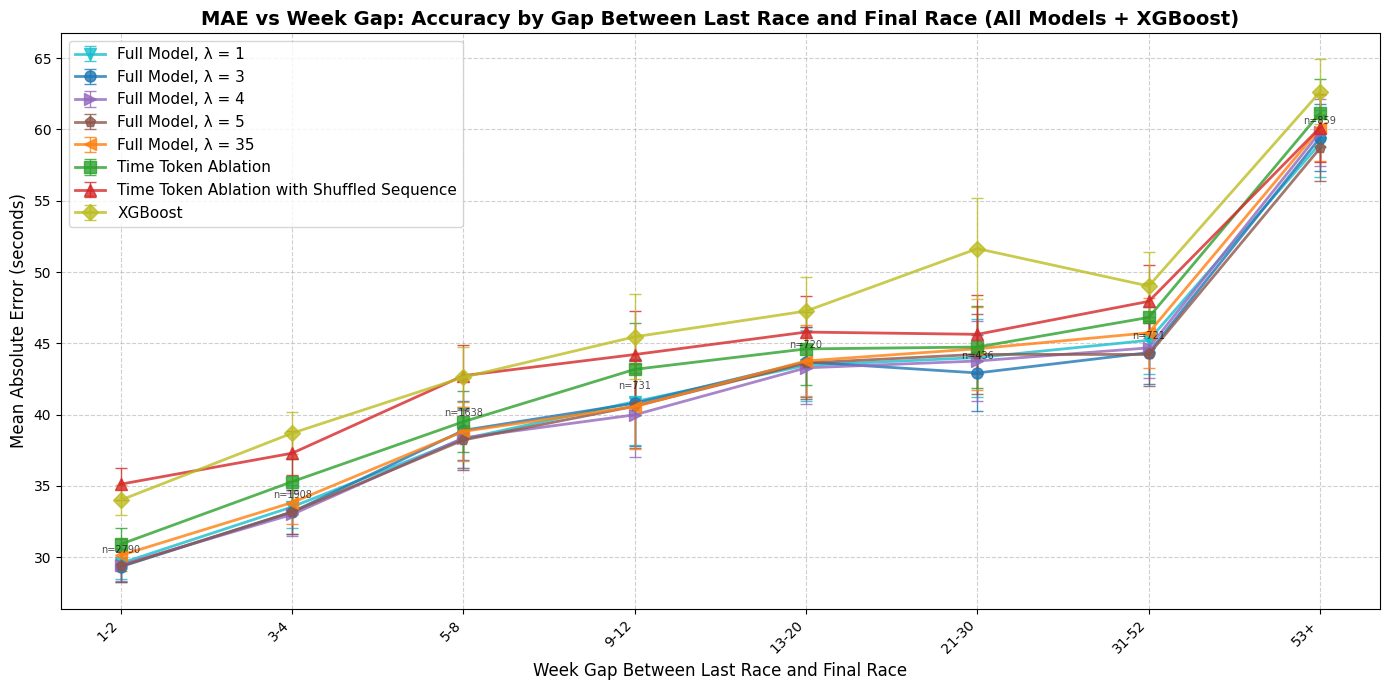


MAE BY WEEK GAP (showing buckets with at least 5 examples)
Week Gap     Samples    Full Model, λ = 1                   Full Model, λ = 3                   Full Model, λ = 4                   Full Model, λ = 5                   Full Model, λ = 35                  Time Token Ablation                 Time Token Ablation with Shuffled Sequence XGBoost                            
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1-2          2790       29.58                               29.34                               29.46                               29.37                               30.14                               30.92                               35.13                               34.01                     

In [16]:
# Compute MAE grouped by week gap between last race and final race
# Reuse week_delta data computed in Step 8

def bucket_week_delta(wd):
    """Bucket week deltas into ranges for better statistics."""
    if wd is None:
        return None
    if wd == 0:
        return 0
    elif wd <= 2:
        return "1-2"
    elif wd <= 4:
        return "3-4"
    elif wd <= 8:
        return "5-8"
    elif wd <= 12:
        return "9-12"
    elif wd <= 20:
        return "13-20"
    elif wd <= 30:
        return "21-30"
    elif wd <= 52:
        return "31-52"
    else:
        return "53+"

def get_week_delta_bucket_label(bucket):
    """Get display label for a week delta bucket."""
    if isinstance(bucket, int):
        return str(bucket)
    return bucket

def get_week_delta_sort_key(bucket):
    """Get a sort key for a week delta bucket to ensure proper ordering."""
    if isinstance(bucket, int):
        return bucket
    # For string buckets, use the start value
    if bucket == "53+":
        return 1000  # Put at the end
    parts = bucket.split('-')
    return int(parts[0])

print("Grouping MAE data by week gap between last race and final race...")

# Check if we have the data from the previous cell
if 'mae_examples' not in globals() or 'results' not in globals():
    print("❌ ERROR: Please run the MAE comparison cell (Step 7) first!")
    print("   The week gap analysis requires the data from that cell.")
elif 'example_week_deltas' not in globals():
    print("❌ ERROR: Please run the MAE vs history length cell (Step 8) first!")
    print("   The week gap analysis requires week_delta data computed in that cell.")
else:
    print(f"✓ Using week_delta data computed in Step 8\n")
    
    # Track errors by week delta for each model
    results_by_week_delta = defaultdict(lambda: {
        MODEL_NAME_1: [],
        MODEL_NAME_2: [],
        MODEL_NAME_3: [],
        MODEL_NAME_4: [],
        MODEL_NAME_5: [],
        MODEL_NAME_6: [],
        MODEL_NAME_7: [],
        'XGBoost': []
    })
    
    # Get the successful indices from XGBoost results, or use all examples if XGBoost not available
    if 'XGBoost' in results and 'successful_indices' in results['XGBoost']:
        valid_indices = results['XGBoost']['successful_indices']
        print(f"  Using {len(valid_indices)} examples (where XGBoost succeeded) for apples-to-apples comparison")
    else:
        valid_indices = list(range(len(mae_examples)))
        print(f"  Using all {len(valid_indices)} examples (XGBoost not available)")
    
    # Group errors by week delta (reusing already-computed week_deltas and errors)
    for error_idx, example_idx in enumerate(valid_indices):
        if example_idx >= len(mae_examples):
            continue
        
        # Get week_delta from pre-computed data
        week_delta = example_week_deltas.get(example_idx)
        if week_delta is None:
            continue
        
        # Bucket the week delta
        bucket = bucket_week_delta(week_delta)
        if bucket is None:
            continue
        
        # All models are evaluated on the same examples, so errors are aligned by error_idx
        # Order: Lambda 1, 3, 4, 5, 35, then Ablation models
        for model_name in [MODEL_NAME_4, MODEL_NAME_1, MODEL_NAME_6, MODEL_NAME_7, MODEL_NAME_5, MODEL_NAME_2, MODEL_NAME_3, 'XGBoost']:
            if model_name in results and 'errors_median' in results[model_name]:
                if error_idx < len(results[model_name]['errors_median']):
                    error = results[model_name]['errors_median'][error_idx]
                    results_by_week_delta[bucket][model_name].append(error)
    
    print(f"✓ Grouped errors by week gap\n")
    
    # Get sorted bucket labels for plotting
    all_buckets = list(results_by_week_delta.keys())
    week_delta_buckets = sorted(all_buckets, key=get_week_delta_sort_key)
    
    plt.figure(figsize=(14, 7))
    
    
    # Note: model_labels, model_colors, and model_markers are defined in Cell 4
    
    # Plot each model
    # Order: Lambda 1, 3, 4, 5, then Ablation models
    models_to_plot = list(MODELS_PLOT_ORDER)  # copy to avoid mutating global list
    if 'XGBoost' in results:
        models_to_plot.append('XGBoost')
    
    # Create mapping from bucket to x-axis position
    bucket_to_pos = {bucket: i for i, bucket in enumerate(week_delta_buckets)}
    
    for model_name in models_to_plot:
        # Only include buckets with at least 5 examples
        valid_buckets = [b for b in week_delta_buckets if len(results_by_week_delta[b][model_name]) >= 5]
        valid_positions = [bucket_to_pos[b] for b in valid_buckets]
        maes = [np.mean(results_by_week_delta[b][model_name]) for b in valid_buckets]
        # Calculate Standard Error of the Mean (SEM)
        sems = [np.std(results_by_week_delta[b][model_name]) / np.sqrt(len(results_by_week_delta[b][model_name])) 
                for b in valid_buckets]
        
        color = model_colors.get(model_name, 'gray')
        marker = model_markers.get(model_name, 'o')
        label = model_labels.get(model_name, model_name)
        
        plt.errorbar(valid_positions, maes, yerr=sems, marker=marker, label=label,
                     color=color, linewidth=2, markersize=8, capsize=4, elinewidth=1, alpha=0.8)
        
        # Annotate sample sizes for first model
        if model_name == MODEL_NAME_1:
            for pos, bucket, val in zip(valid_positions, valid_buckets, maes):
                n_samples = len(results_by_week_delta[bucket][model_name])
                plt.annotate(f'n={n_samples}', (pos, val), textcoords="offset points", 
                            xytext=(0, 10), ha='center', fontsize=7, alpha=0.7)
    
    title = 'MAE vs Week Gap: Accuracy by Gap Between Last Race and Final Race'
    if 'XGBoost' in results:
        title += ' (All Models + XGBoost)'
    else:
        title += ' (All 3 Models)'
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Week Gap Between Last Race and Final Race', fontsize=12)
    plt.ylabel('Mean Absolute Error (seconds)', fontsize=12)
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    # Set x-axis labels
    bucket_labels = [get_week_delta_bucket_label(b) for b in week_delta_buckets]
    plt.xticks(range(len(week_delta_buckets)), bucket_labels, rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*80}")
    print("MAE BY WEEK GAP (showing buckets with at least 5 examples)")
    print(f"{'='*80}")
    # Order: Lambda 1, 3, 4, 5, then Ablation models
    header_models = list(MODELS_PLOT_ORDER)  # copy to avoid mutating global list
    if 'XGBoost' in results:
        header_models.append('XGBoost')
    # Use model_labels for display names
    header_labels = [model_labels.get(m, m) for m in header_models]
    header = f"{'Week Gap':<12} {'Samples':<10} " + " ".join([f"{m:<35}" for m in header_labels])
    print(header)
    print("-" * len(header))
    for bucket in week_delta_buckets:
        counts = [len(results_by_week_delta[bucket][m]) for m in header_models]
        if max(counts) >= 5:
            sample_count = max(counts)
            maes = [np.mean(results_by_week_delta[bucket][m]) if len(results_by_week_delta[bucket][m]) >= 5 else np.nan
                    for m in header_models]
            maes_str = " ".join([f"{m:<35.2f}" for m in maes])
            bucket_label = get_week_delta_bucket_label(bucket)
            print(f"{bucket_label:<12} {sample_count:<10} {maes_str}")


## Step 11: Calibration Analysis for All Transformer Models

Plot calibration plots (histogram, KS test, Q-Q plot, calibration curve) for all 3 transformer models.


Calibration Analysis for All Transformer Models
✓ Using percentile data from Step 7

1. Creating histogram of percentiles (quantile bin distribution)...


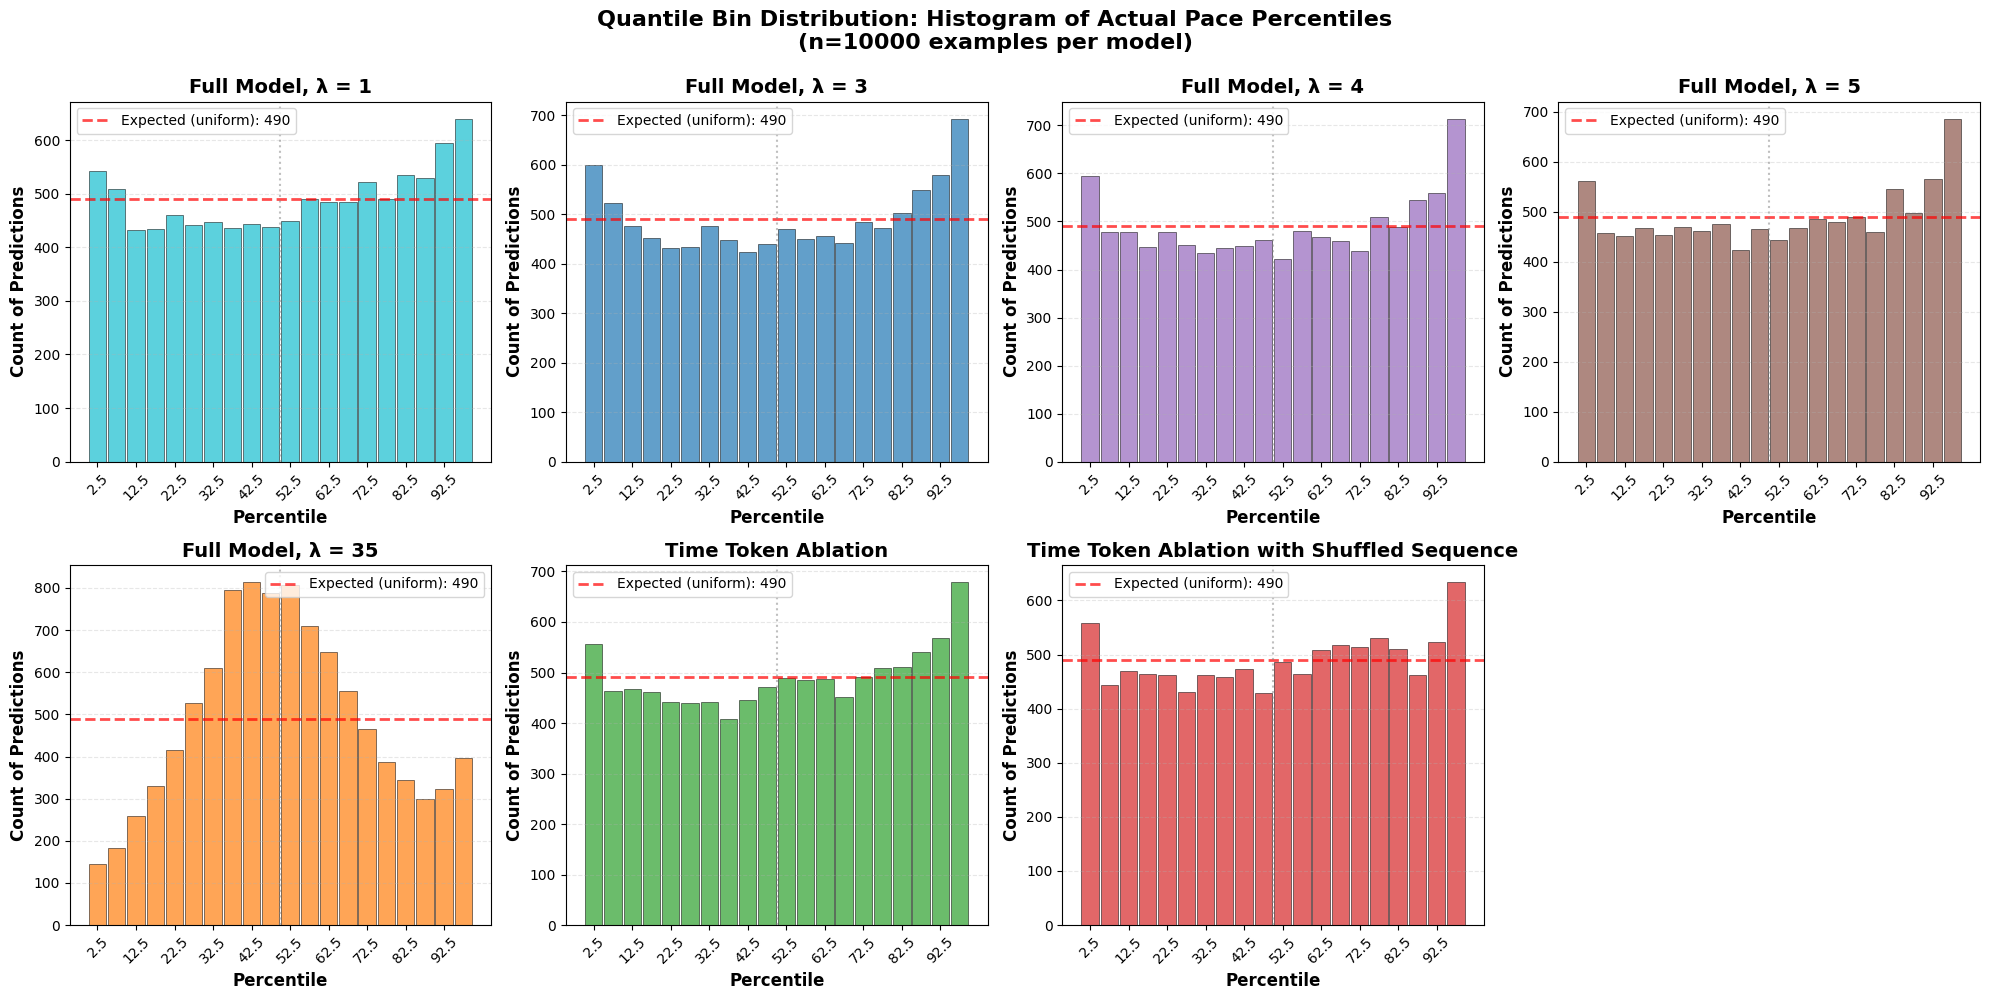


   Creating combined histogram...


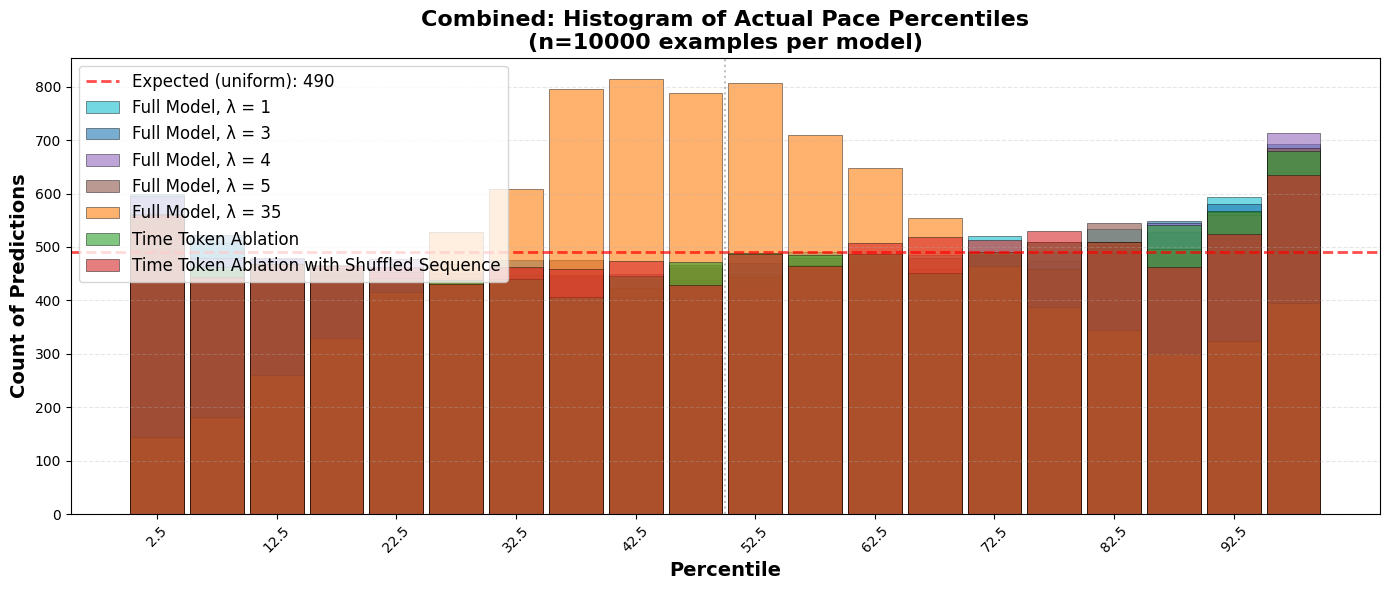


2. Performing Kolmogorov-Smirnov test...
CALIBRATION TEST (Kolmogorov-Smirnov)
Null hypothesis: Percentiles follow Uniform(0,1) distribution

Full Model, λ = 1:
  KS statistic: 0.039203
  P-value: 0.000000
  ❌ p-value < 0.05: Significantly non-uniform (model appears miscalibrated)

Full Model, λ = 3:
  KS statistic: 0.037422
  P-value: 0.000000
  ❌ p-value < 0.05: Significantly non-uniform (model appears miscalibrated)

Full Model, λ = 4:
  KS statistic: 0.038012
  P-value: 0.000000
  ❌ p-value < 0.05: Significantly non-uniform (model appears miscalibrated)

Full Model, λ = 5:
  KS statistic: 0.034514
  P-value: 0.000000
  ❌ p-value < 0.05: Significantly non-uniform (model appears miscalibrated)

Full Model, λ = 35:
  KS statistic: 0.115357
  P-value: 0.000000
  ❌ p-value < 0.05: Significantly non-uniform (model appears miscalibrated)

Time Token Ablation:
  KS statistic: 0.037857
  P-value: 0.000000
  ❌ p-value < 0.05: Significantly non-uniform (model appears miscalibrated)

Time Tok

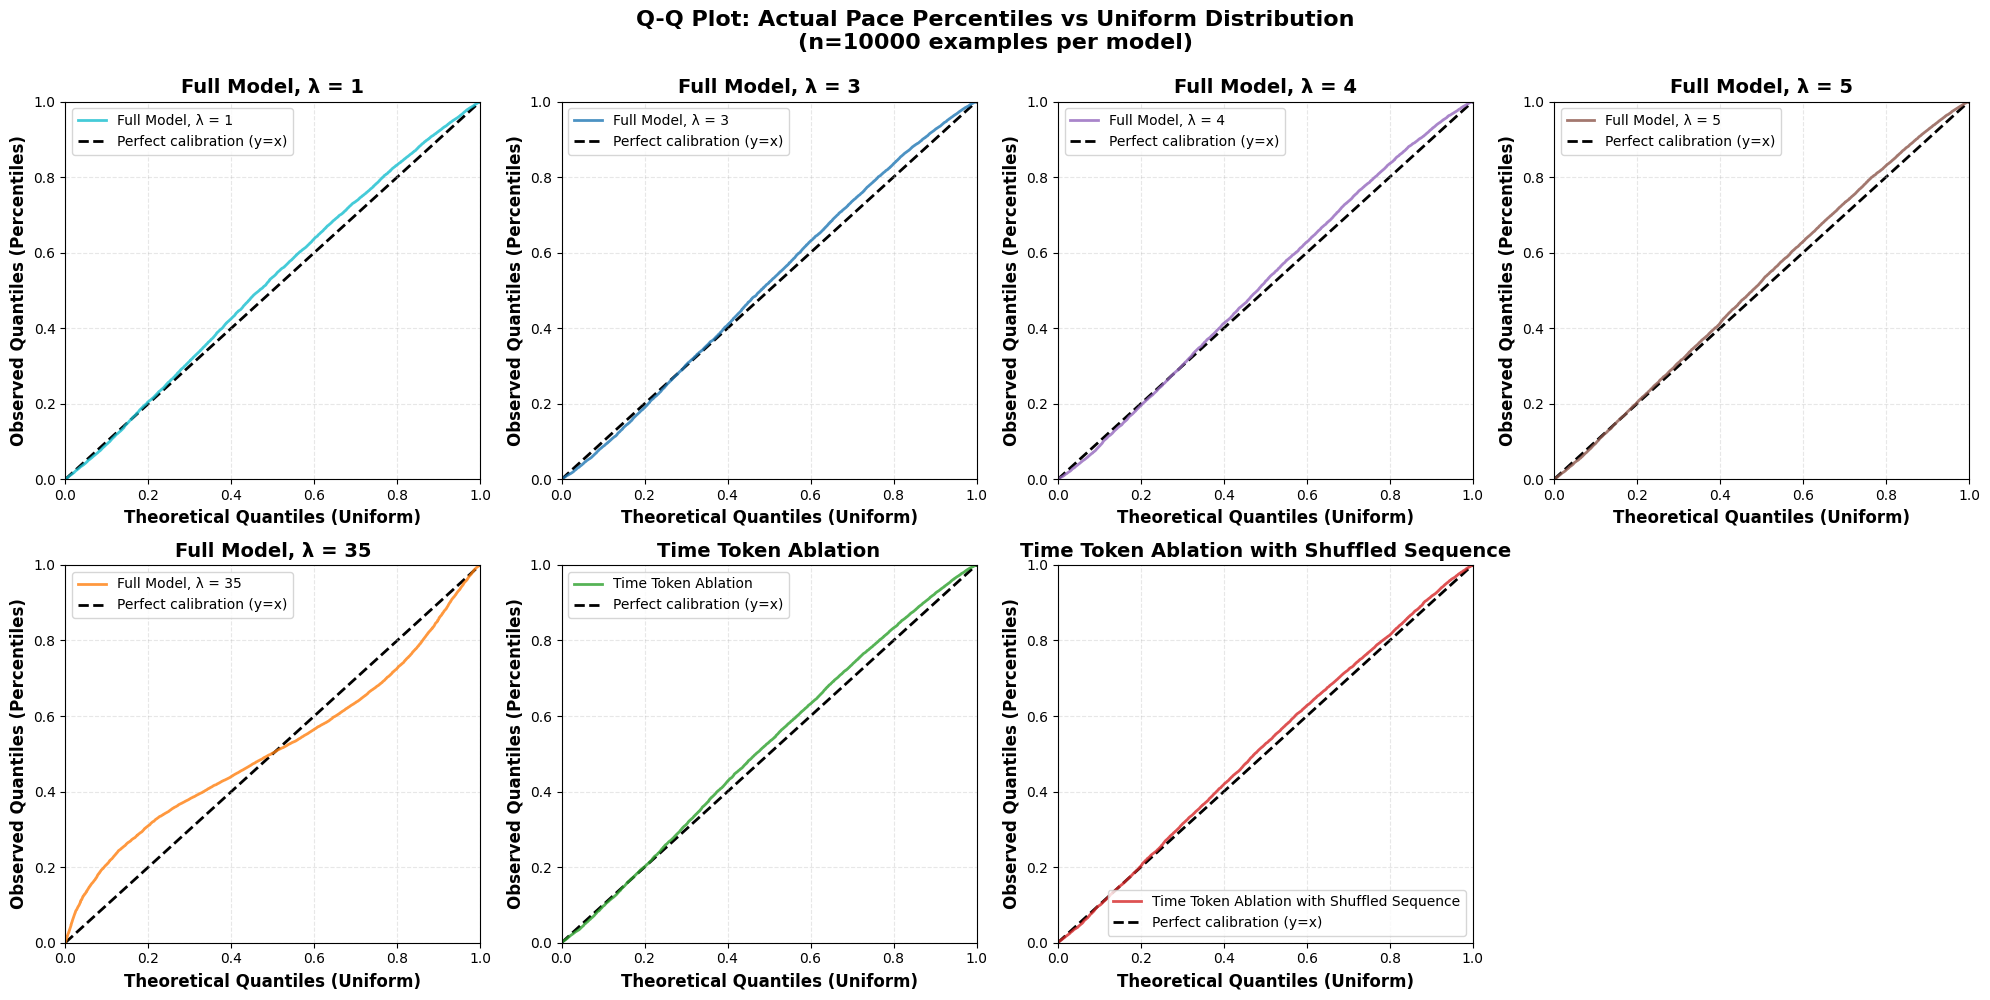


   Creating combined Q-Q plot...


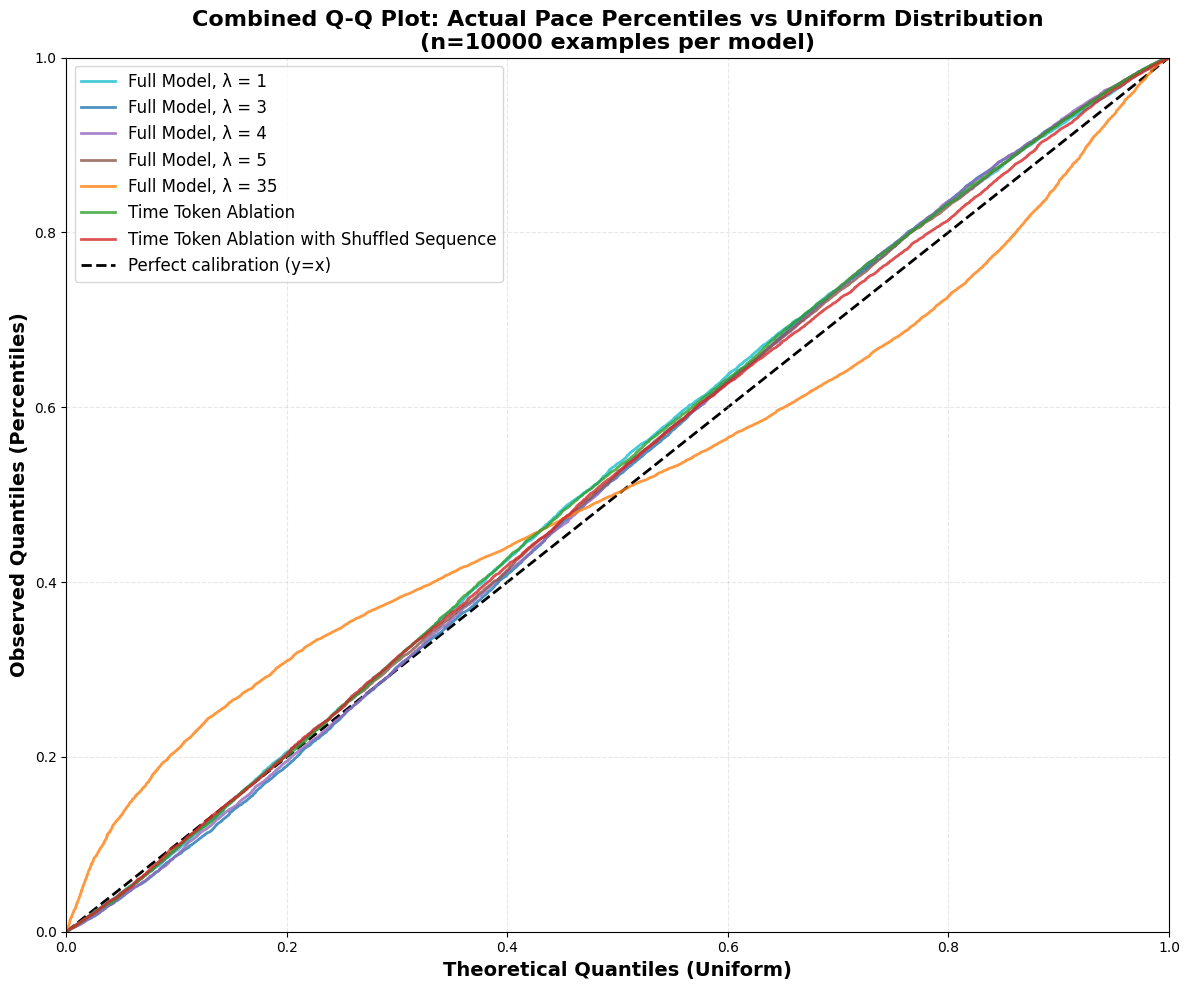

Q-Q Plots created.
If well-calibrated, points should fall along the diagonal line (y=x).
Deviations indicate miscalibration:
  - Points above diagonal: model underestimates uncertainty
  - Points below diagonal: model overestimates uncertainty

4. Creating calibration curve...
CALIBRATION PLOT



KeyboardInterrupt: 

In [17]:
# Calibration analysis for all 3 transformer models
# Reuse percentile data computed in Step 7

from scipy.stats import kstest
from sklearn.calibration import calibration_curve

MAX_CALIBRATION_EXAMPLES = 10000


print("Calibration Analysis for All Transformer Models")
print("="*80)

# Check if we have percentile data from Step 7
if 'percentiles_by_model' not in globals() or len(percentiles_by_model) == 0:
    print("❌ ERROR: Please run the MAE comparison cell (Step 7) first!")
    print("   The calibration analysis requires percentile data computed in that cell.")
else:
    print(f"✓ Using percentile data from Step 7\n")
    
    # Limit to first 10,000 examples for calibration plots (as in Examine_Distribution_Quantile_Predictions)
    
    # Note: model_colors, model_labels, and MODELS_PLOT_ORDER are defined in Cell 4 (centralized definitions)
    # They include all models including MODEL_NAME_5 (Full Model, λ = 35) and XGBoost
    
    # --- 1. HISTOGRAM OF PERCENTILES (QUANTILE BIN DISTRIBUTION) ---
    print("1. Creating histogram of percentiles (quantile bin distribution)...")
    
    # Create subplots for each model (2x4 grid for 7 models)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()  # Flatten to 1D array for easier indexing
    fig.suptitle(f'Quantile Bin Distribution: Histogram of Actual Pace Percentiles\n(n={MAX_CALIBRATION_EXAMPLES} examples per model)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    # Convert percentiles to fractions (0-1 range) for binning
    bin_edges = np.arange(0, 1.05, 0.05)  # 0, 0.05, 0.10, ..., 1.0
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0 * 100  # Convert to percentage for x-axis
    num_bins = len(bin_edges) - 1  # Number of bins (20 bins for 0.05 spacing)
    
    # Use only transformer models we have labels for (should be 6 models)
    models_for_hist = [m for m in MODELS_PLOT_ORDER if m in model_labels]
    
    for idx, model_name in enumerate(models_for_hist):
        if idx >= len(axes):
            break
        ax = axes[idx]
        
        if model_name not in percentiles_by_model or len(percentiles_by_model[model_name]) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(model_labels.get(model_name, model_name), fontsize=14, fontweight='bold')
            continue
        
        percentiles = percentiles_by_model[model_name][:MAX_CALIBRATION_EXAMPLES]
        percentiles_fraction = np.array(percentiles) / 100.0
        
        # Compute expected count based on actual number of percentiles (not the max limit)
        actual_count = len(percentiles_fraction)
        expected_count = actual_count / num_bins  # Expected count per bin for uniform distribution
        
        # Compute histogram
        counts, _ = np.histogram(percentiles_fraction, bins=bin_edges)
        
        # Plot
        color = model_colors.get(model_name, 'gray')
        label = model_labels.get(model_name, model_name)
        ax.bar(bin_centers, counts, width=4.5, alpha=0.7, color=color, edgecolor='black', linewidth=0.5)
        
        # Add expected uniform distribution line
        ax.axhline(expected_count, color='red', linestyle='--', linewidth=2, alpha=0.7, 
                  label=f'Expected (uniform): {expected_count:.0f}')
        ax.axvline(50, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)
        
        ax.set_xlabel('Percentile', fontsize=12, fontweight='bold')
        ax.set_ylabel('Count of Predictions', fontsize=12, fontweight='bold')
        ax.set_title(label, fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.set_xticks(bin_centers[::2])
        ax.tick_params(axis='x', rotation=45)
    
    # Hide unused subplots (if we have fewer than 8 models)
    for idx in range(len(models_for_hist), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Also create a combined plot
    print("\n   Creating combined histogram...")
    plt.figure(figsize=(14, 6))
    
    # Compute expected count based on the first model's actual count (all models should have same count)
    first_model_count = None
    for model_name in MODELS_PLOT_ORDER:
        if model_name in percentiles_by_model and len(percentiles_by_model[model_name]) > 0:
            first_model_count = len(percentiles_by_model[model_name][:MAX_CALIBRATION_EXAMPLES])
            break
    
    if first_model_count is not None:
        expected_count_combined = first_model_count / num_bins
    else:
        expected_count_combined = MAX_CALIBRATION_EXAMPLES / num_bins
    
    for model_name in MODELS_PLOT_ORDER:
        if model_name not in percentiles_by_model or len(percentiles_by_model[model_name]) == 0:
            continue
        
        percentiles = percentiles_by_model[model_name][:MAX_CALIBRATION_EXAMPLES]
        percentiles_fraction = np.array(percentiles) / 100.0
        
        # Compute histogram
        counts, _ = np.histogram(percentiles_fraction, bins=bin_edges)
        
        # Plot
        color = model_colors.get(model_name, 'gray')
        label = model_labels.get(model_name, model_name)
        plt.bar(bin_centers, counts, width=4.5, alpha=0.6, label=label, color=color, edgecolor='black', linewidth=0.5)
    
    plt.axhline(expected_count_combined, color='red', linestyle='--', linewidth=2, alpha=0.7, 
               label=f'Expected (uniform): {expected_count_combined:.0f}')
    plt.xlabel('Percentile', fontsize=14, fontweight='bold')
    plt.ylabel('Count of Predictions', fontsize=14, fontweight='bold')
    plt.title(f'Combined: Histogram of Actual Pace Percentiles\n(n={MAX_CALIBRATION_EXAMPLES} examples per model)', 
              fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--', axis='y')
    plt.xticks(bin_centers[::2], rotation=45)
    plt.axvline(50, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    # --- 2. KOLMOGOROV-SMIRNOV TEST ---
    print("\n2. Performing Kolmogorov-Smirnov test...")
    print("="*80)
    print("CALIBRATION TEST (Kolmogorov-Smirnov)")
    print("="*80)
    print("Null hypothesis: Percentiles follow Uniform(0,1) distribution\n")
    
    for model_name in MODELS_PLOT_ORDER:
        if model_name not in percentiles_by_model or len(percentiles_by_model[model_name]) == 0:
            continue
        
        percentiles = percentiles_by_model[model_name][:MAX_CALIBRATION_EXAMPLES]
        percentiles_fraction = np.array(percentiles) / 100.0
        
        statistic, pvalue = kstest(percentiles_fraction, 'uniform')
        
        label = model_labels[model_name]
        print(f"{label}:")
        print(f"  KS statistic: {statistic:.6f}")
        print(f"  P-value: {pvalue:.6f}")
        if pvalue < 0.05:
            print(f"  ❌ p-value < 0.05: Significantly non-uniform (model appears miscalibrated)")
        else:
            print(f"  ✅ p-value >= 0.05: Cannot reject uniformity (model appears well-calibrated)")
        print()
    
    # --- 3. Q-Q PLOTS (Separate for each model) ---
    print("3. Creating Q-Q plots...")
    
    # Create separate Q-Q plots for each model (2x4 grid for 7 models)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()  # Flatten to 1D array for easier indexing
    fig.suptitle(f'Q-Q Plot: Actual Pace Percentiles vs Uniform Distribution\n(n={MAX_CALIBRATION_EXAMPLES} examples per model)', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    for idx, model_name in enumerate(MODELS_PLOT_ORDER):
        if idx >= len(axes):
            break
        ax = axes[idx]
        
        if model_name not in percentiles_by_model or len(percentiles_by_model[model_name]) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(model_labels.get(model_name, model_name), fontsize=14, fontweight='bold')
            continue
        
        percentiles = percentiles_by_model[model_name][:MAX_CALIBRATION_EXAMPLES]
        percentiles_fraction = np.array(percentiles) / 100.0
        
        # Sort percentiles for Q-Q plot
        sorted_percentiles = np.sort(percentiles_fraction)
        
        # Theoretical quantiles from uniform distribution
        n = len(sorted_percentiles)
        theoretical_quantiles = np.linspace(0, 1, n)
        
        color = model_colors.get(model_name, 'gray')
        label = model_labels.get(model_name, model_name)
        
        # Use line plot instead of scatter for cleaner visualization
        ax.plot(theoretical_quantiles, sorted_percentiles, color=color, linewidth=2, 
                label=label, alpha=0.8)
        ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect calibration (y=x)', zorder=1)
        
        ax.set_xlabel('Theoretical Quantiles (Uniform)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Observed Quantiles (Percentiles)', fontsize=12, fontweight='bold')
        ax.set_title(label, fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    
    # Hide unused subplots (if we have fewer than 8 models)
    num_plotted = min(len(MODELS_PLOT_ORDER), len(axes))
    for idx in range(num_plotted, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Also create a combined Q-Q plot
    print("\n   Creating combined Q-Q plot...")
    plt.figure(figsize=(12, 10))
    
    for model_name in MODELS_PLOT_ORDER:
        if model_name not in percentiles_by_model or len(percentiles_by_model[model_name]) == 0:
            continue
        
        percentiles = percentiles_by_model[model_name][:MAX_CALIBRATION_EXAMPLES]
        percentiles_fraction = np.array(percentiles) / 100.0
        
        # Sort percentiles for Q-Q plot
        sorted_percentiles = np.sort(percentiles_fraction)
        
        # Theoretical quantiles from uniform distribution
        n = len(sorted_percentiles)
        theoretical_quantiles = np.linspace(0, 1, n)
        
        color = model_colors.get(model_name, 'gray')
        label = model_labels.get(model_name, model_name)
        # Use line plot instead of scatter for cleaner visualization (matching individual Q-Q plots)
        plt.plot(theoretical_quantiles, sorted_percentiles, color=color, linewidth=2, 
                label=label, alpha=0.8)
    
    # Add diagonal reference line (matching individual Q-Q plots)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect calibration (y=x)', zorder=1)
    plt.xlabel('Theoretical Quantiles (Uniform)', fontsize=14, fontweight='bold')
    plt.ylabel('Observed Quantiles (Percentiles)', fontsize=14, fontweight='bold')
    plt.title(f'Combined Q-Q Plot: Actual Pace Percentiles vs Uniform Distribution\n(n={MAX_CALIBRATION_EXAMPLES} examples per model)', 
              fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
    
    print("Q-Q Plots created.")
    print("If well-calibrated, points should fall along the diagonal line (y=x).")
    print("Deviations indicate miscalibration:")
    print("  - Points above diagonal: model underestimates uncertainty")
    print("  - Points below diagonal: model overestimates uncertainty")
    
    # --- 4. CALIBRATION CURVE ---
    print("\n4. Creating calibration curve...")
    print("="*80)
    print("CALIBRATION PLOT")
    print("="*80)
    print("Collecting calibration data from examples...\n")
    
    # Collect calibration data for all models
    calibration_data = {}
    
    for model_name in MODELS_PLOT_ORDER:
        if model_name not in percentiles_by_model or len(percentiles_by_model[model_name]) == 0:
            continue
        
        # Get the inference model to access pace_bins
        # Use inferences_dict which maps all model names to their inference objects
        if model_name in inferences_dict:
            inference_model = inferences_dict[model_name]
        else:
            # Fallback (should not happen if all models are loaded)
            print(f"  ⚠️  Warning: {model_name} not found in inferences_dict, skipping")
            continue
        
        predicted_probs = []
        actual_outcomes = []
        
        # Use the same examples that were used for percentile computation
        valid_indices = xgb_successful_indices[:MAX_CALIBRATION_EXAMPLES]
        
        for idx, example_idx in enumerate(valid_indices):
            if example_idx >= len(mae_examples):
                continue
            
            ex = mae_examples[example_idx]
            actual_pace = ex.actual_pace_seconds
            
            # Get prediction result
            result = inference_model.predict_from_raw_example(ex)
            
            # Sample multiple random thresholds for each example
            n_samples_per_example = 5
            for _ in range(n_samples_per_example):
                # Pick a random threshold bin
                threshold_bin = np.random.randint(0, len(inference_model.pace_bins))
                
                # Predicted probability of pace being <= threshold (CDF)
                probs = result['probabilities']
                probs_normalized = probs / probs.sum() if probs.sum() > 0 else probs
                cdf_at_threshold = np.cumsum(probs_normalized)[threshold_bin]
                
                pred_prob = cdf_at_threshold
                
                # Actual outcome: did actual pace <= threshold?
                bin_ends = np.array([b['end'] for b in inference_model.pace_bins])
                threshold_value = bin_ends[threshold_bin]
                actual = 1 if actual_pace <= threshold_value else 0
                
                predicted_probs.append(pred_prob)
                actual_outcomes.append(actual)
        
        # Clip probabilities to [0, 1]
        predicted_probs = np.clip(np.array(predicted_probs), 0.0, 1.0)
        actual_outcomes = np.array(actual_outcomes)
        
        calibration_data[model_name] = {
            'predicted_probs': predicted_probs,
            'actual_outcomes': actual_outcomes
        }
        
        print(f"  {model_labels.get(model_name, model_name)}: Collected {len(predicted_probs)} data points from {len(valid_indices)} examples")
    
    print()
    
    # Plot calibration curves for all models
    plt.figure(figsize=(12, 10))
    
    for model_name in MODELS_PLOT_ORDER:
        if model_name not in calibration_data:
            continue
        
        predicted_probs = calibration_data[model_name]['predicted_probs']
        actual_outcomes = calibration_data[model_name]['actual_outcomes']
        
        # Check if we have both 0 and 1 in actual_outcomes
        unique_outcomes = np.unique(actual_outcomes)
        if len(unique_outcomes) < 2:
            print(f"⚠️  Warning: {model_labels.get(model_name, model_name)} - Only found {unique_outcomes} in outcomes. Skipping calibration curve.")
            continue
        
        # Create calibration curve
        try:
            fraction_of_positives, mean_predicted_value = calibration_curve(
                actual_outcomes, predicted_probs, n_bins=10, strategy='uniform', pos_label=1
            )
            
            color = model_colors.get(model_name, 'gray')
            label = model_labels.get(model_name, model_name)
            plt.plot(mean_predicted_value, fraction_of_positives, 's-', markersize=10, 
                    linewidth=2, label=label, color=color, alpha=0.8)
        except Exception as e:
            print(f"⚠️  Warning: {model_labels.get(model_name, model_name)} - Error creating calibration curve: {e}")
            continue
    
    plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration', zorder=1)
    plt.xlabel('Mean Predicted Probability', fontsize=14, fontweight='bold')
    plt.ylabel('Observed Frequency', fontsize=14, fontweight='bold')
    plt.title('Calibration Plot: Predicted vs Observed Frequencies\n' + 
              f'(n={MAX_CALIBRATION_EXAMPLES} examples per model)', 
              fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nCalibration Summary:")
    print("-" * 80)
    for model_name in MODELS_PLOT_ORDER:
        if model_name not in calibration_data:
            continue
        
        predicted_probs = calibration_data[model_name]['predicted_probs']
        actual_outcomes = calibration_data[model_name]['actual_outcomes']
        
        print(f"{model_labels.get(model_name, model_name)}:")
        print(f"  Total predictions: {len(predicted_probs)}")
        print(f"  Mean predicted probability: {predicted_probs.mean():.3f}")
        print(f"  Mean observed frequency: {actual_outcomes.mean():.3f}")
        print()
    
    print("Interpretation:")
    print("  - Points on the diagonal (dashed line) = perfect calibration")
    print("  - Points above diagonal = model overconfident (predicts too high)")
    print("  - Points below diagonal = model underconfident (predicts too low)")
    print("="*80)


## Step 12: Calibration Analysis by Pace Deciles

Analyze calibration (Q-Q plots and KS statistics) separately for each 10% decile of true race paces.
This helps identify if calibration varies across different pace ranges.

For now, analyzing MODEL_NAME_1 (Lambda = 3) only.


CALIBRATION ANALYSIS BY PACE DECILES
Analyzing model: Full Model, λ = 3

✓ Collected 986 examples
  Actual pace range: 317.0s to 1288.0s

Decile boundaries:
  Decile 1: 0-97 examples, pace range: 317.0s - 438.0s
  Decile 2: 98-195 examples, pace range: 438.0s - 478.0s
  Decile 3: 196-293 examples, pace range: 478.0s - 508.0s
  Decile 4: 294-391 examples, pace range: 509.0s - 531.0s
  Decile 5: 392-489 examples, pace range: 531.0s - 551.0s
  Decile 6: 490-587 examples, pace range: 551.0s - 579.0s
  Decile 7: 588-685 examples, pace range: 579.0s - 610.0s
  Decile 8: 686-783 examples, pace range: 610.0s - 649.0s
  Decile 9: 784-881 examples, pace range: 649.0s - 707.0s
  Decile 10: 882-985 examples, pace range: 710.0s - 1288.0s



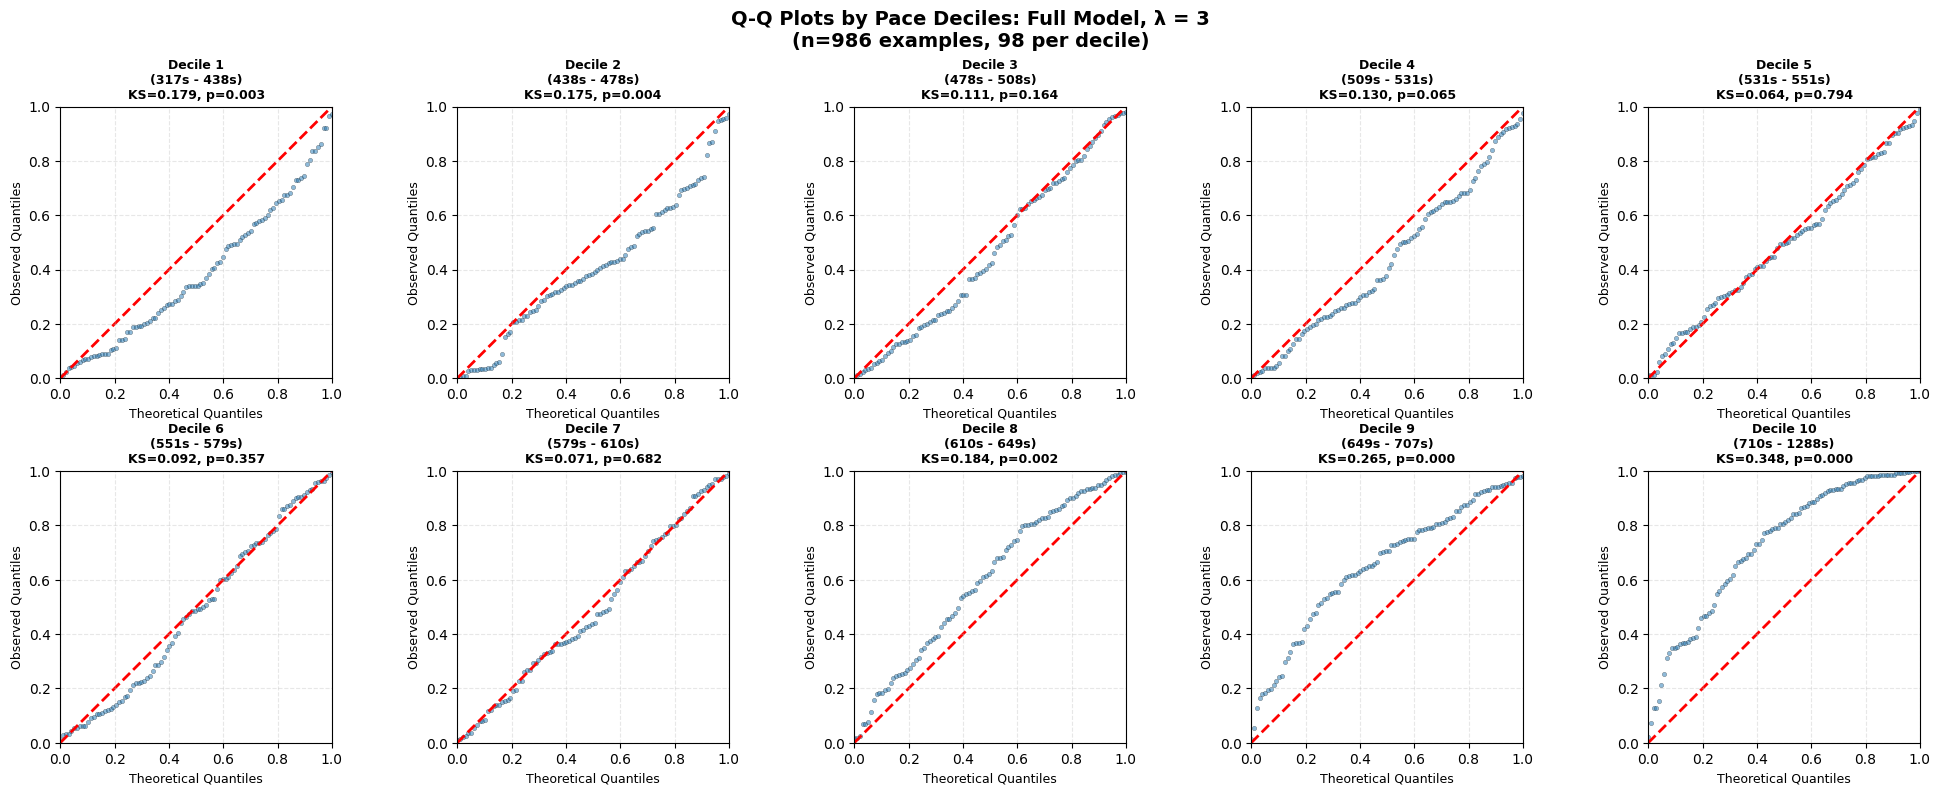

CALIBRATION SUMMARY BY DECILE
Decile   Pace Range           N      KS Stat    P-value    Calibrated? 
--------------------------------------------------------------------------------
1        317s - 438s      98     0.1792     0.0032     No          
2        438s - 478s      98     0.1746     0.0044     No          
3        478s - 508s      98     0.1112     0.1643     Yes         
4        509s - 531s      98     0.1304     0.0652     Yes         
5        531s - 551s      98     0.0639     0.7940     Yes         
6        551s - 579s      98     0.0919     0.3571     Yes         
7        579s - 610s      98     0.0708     0.6823     Yes         
8        610s - 649s      98     0.1843     0.0022     No          
9        649s - 707s      98     0.2649     0.0000     No          
10       710s - 1288s      104    0.3482     0.0000     No          

Interpretation:
  - KS Statistic: Lower is better (0 = perfect calibration)
  - P-value > 0.05: Cannot reject uniformity (well-calibrat

In [ ]:
from scipy.stats import kstest
import numpy as np
import matplotlib.pyplot as plt

# Specify which model to analyze
MODEL_TO_ANALYZE = MODEL_NAME_1  # Lambda = 3

print("="*80)
print("CALIBRATION ANALYSIS BY PACE DECILES")
print("="*80)
display_label = model_labels.get(MODEL_TO_ANALYZE, MODEL_TO_ANALYZE)
print(f"Analyzing model: {display_label}")
print()

# Check if we have the required data
if MODEL_TO_ANALYZE not in percentiles_by_model:
    print(f"❌ ERROR: Model {MODEL_TO_ANALYZE} not found in percentiles_by_model")
    print(f"   Available models: {list(percentiles_by_model.keys())}")
    print(f"   Please run Step 7 first to compute percentiles.")
else:
    # Collect actual paces and percentiles for this model
    print("Collecting actual paces and percentiles...")
    actual_paces = []
    percentiles = []
    
    # Use the same examples that were used for calibration (xgb_successful_indices)
    for idx, i in enumerate(xgb_successful_indices):
        ex = mae_examples[i]
        actual_pace = ex.actual_pace_seconds
        percentile = percentiles_by_model[MODEL_TO_ANALYZE][idx]
        
        actual_paces.append(actual_pace)
        percentiles.append(percentile)
    
    actual_paces = np.array(actual_paces)
    percentiles = np.array(percentiles)
    
    print(f"✓ Collected {len(actual_paces)} examples")
    print(f"  Actual pace range: {actual_paces.min():.1f}s to {actual_paces.max():.1f}s")
    print()
    
    # Sort by actual pace
    sort_indices = np.argsort(actual_paces)
    sorted_actual_paces = actual_paces[sort_indices]
    sorted_percentiles = percentiles[sort_indices]
    
    # Divide into 10 deciles
    n_examples = len(sorted_actual_paces)
    decile_size = n_examples // 10
    decile_boundaries = []
    
    for i in range(10):
        start_idx = i * decile_size
        end_idx = (i + 1) * decile_size if i < 9 else n_examples
        decile_boundaries.append((start_idx, end_idx))
    
    print("Decile boundaries:")
    for i, (start, end) in enumerate(decile_boundaries):
        pace_min = sorted_actual_paces[start]
        pace_max = sorted_actual_paces[end - 1]
        print(f"  Decile {i+1}: {start}-{end-1} examples, pace range: {pace_min:.1f}s - {pace_max:.1f}s")
    print()
    
    # Create Q-Q plots for each decile
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    ks_statistics = []
    ks_pvalues = []
    
    for decile_idx in range(10):
        start, end = decile_boundaries[decile_idx]
        decile_percentiles = sorted_percentiles[start:end]
        
        # Convert to 0-1 range for Q-Q plot
        decile_percentiles_fraction = decile_percentiles / 100.0
        
        # Sort for Q-Q plot
        sorted_decile_percentiles = np.sort(decile_percentiles_fraction)
        n_decile = len(sorted_decile_percentiles)
        theoretical_quantiles = np.linspace(0, 1, n_decile)
        
        # Compute KS statistic
        ks_stat, ks_pval = kstest(decile_percentiles_fraction, 'uniform')
        ks_statistics.append(ks_stat)
        ks_pvalues.append(ks_pval)
        
        # Plot Q-Q plot
        ax = axes[decile_idx]
        ax.scatter(theoretical_quantiles, sorted_decile_percentiles, alpha=0.5, s=10, edgecolors='black', linewidths=0.3)
        ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect calibration', zorder=1)
        ax.set_xlabel('Theoretical Quantiles', fontsize=9)
        ax.set_ylabel('Observed Quantiles', fontsize=9)
        ax.set_title(f'Decile {decile_idx+1}\n({sorted_actual_paces[start]:.0f}s - {sorted_actual_paces[end-1]:.0f}s)\nKS={ks_stat:.3f}, p={ks_pval:.3f}', 
                    fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal')
    
    plt.suptitle(f'Q-Q Plots by Pace Deciles: {model_labels.get(MODEL_TO_ANALYZE, MODEL_TO_ANALYZE)}\n(n={n_examples} examples, {decile_size} per decile)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print("="*80)
    print("CALIBRATION SUMMARY BY DECILE")
    print("="*80)
    print(f"{'Decile':<8} {'Pace Range':<20} {'N':<6} {'KS Stat':<10} {'P-value':<10} {'Calibrated?':<12}")
    print("-"*80)
    
    for decile_idx in range(10):
        start, end = decile_boundaries[decile_idx]
        pace_min = sorted_actual_paces[start]
        pace_max = sorted_actual_paces[end - 1]
        n_decile = end - start
        ks_stat = ks_statistics[decile_idx]
        ks_pval = ks_pvalues[decile_idx]
        calibrated = "Yes" if ks_pval > 0.05 else "No"
        
        print(f"{decile_idx+1:<8} {pace_min:.0f}s - {pace_max:.0f}s{'':<5} {n_decile:<6} {ks_stat:<10.4f} {ks_pval:<10.4f} {calibrated:<12}")
    
    print("="*80)
    print()
    print("Interpretation:")
    print("  - KS Statistic: Lower is better (0 = perfect calibration)")
    print("  - P-value > 0.05: Cannot reject uniformity (well-calibrated)")
    print("  - P-value < 0.05: Significantly non-uniform (miscalibrated)")
    print()


### Direct Sequence Transformation

You can also use the transformation functions directly if needed:


In [ ]:
# Import transformation functions directly
from runtime_inference import (
    transform_sequence,
    apply_ablation,
    apply_ablation_shuffled,
    swap_pace_time_and_drop_final
)

# Example: Transform a sequence manually
if len(examples) > 0:
    ex = examples[0]
    original_seq = ex.unpadded_example_sequence
    
    # Use the config-based transformation (recommended)
    transformed = transform_sequence(original_seq, inference.config, inference.block_stride)
    
    print(f"Original sequence length: {len(original_seq)}")
    print(f"Transformed sequence length: {len(transformed)}")
    print(f"\nFirst 20 tokens (original): {original_seq[:20]}")
    print(f"First 20 tokens (transformed): {transformed[:20]}")


Original sequence length: 33
Transformed sequence length: 31

First 20 tokens (original): ['age_31', 'gender_m', 'vc_conditions_rain', 'humidity_pct_token_19', 'temperature_f_token_7', 'feels_like_f_token_7', 'wind_speed_mph_token_6', 'distance_name_token_5_miles', 'week_delta_60', 'week_delta_15', 'pace_32', 'age_31', 'gender_m', 'vc_conditions_partially_cloudy', 'humidity_pct_token_10', 'temperature_f_token_7', 'feels_like_f_token_7', 'wind_speed_mph_token_7', 'distance_name_token_half_marathon', 'week_delta_45']
First 20 tokens (transformed): ['age_31', 'gender_m', 'vc_conditions_rain', 'humidity_pct_token_19', 'temperature_f_token_7', 'feels_like_f_token_7', 'wind_speed_mph_token_6', 'distance_name_token_5_miles', 'pace_32', 'week_delta_60', 'week_delta_15', 'age_31', 'gender_m', 'vc_conditions_partially_cloudy', 'humidity_pct_token_10', 'temperature_f_token_7', 'feels_like_f_token_7', 'wind_speed_mph_token_7', 'distance_name_token_half_marathon', 'pace_44']


## Summary

The `runtime_inference` library provides a simple interface for:
- ✅ Loading models from checkpoints
- ✅ Automatically determining the correct data transformation based on config
- ✅ Running inference on raw training examples
- ✅ Getting probability distributions and statistics

The library handles all the complexity of:
- Model architecture matching
- Sequence transformation (standard, ablation, shuffled ablation)
- Tokenization and padding
- Device management (CPU/CUDA/MPS)

Just provide a checkpoint, config, and raw example, and get back a probability distribution!
